<a href="https://colab.research.google.com/github/Ilya-creat/python-group-progject2/blob/colab/gp_2_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Программирование на Python, БИ

## НИУ ВШЭ, 2025-26 учебный год

# Групповой проект №2. DE: Scraping & API

### Общая информация

Дата выдачи: 21.10.2025

Защита проекта: 12.11.2025

И так поехали...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('sstats_data_normal-20251104_100000.csv')

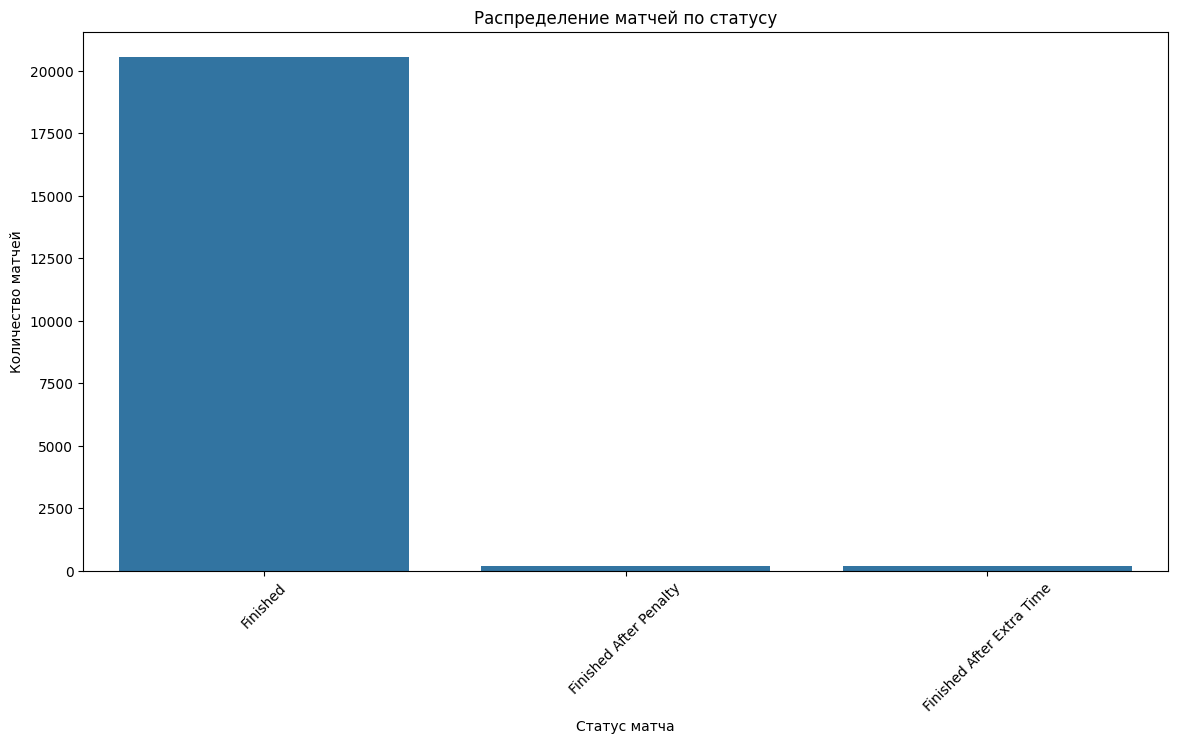

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(x='statusName', data=df)
plt.title('Распределение матчей по статусу')
plt.xlabel('Статус матча')
plt.ylabel('Количество матчей')
plt.xticks(rotation=45)
plt.show()

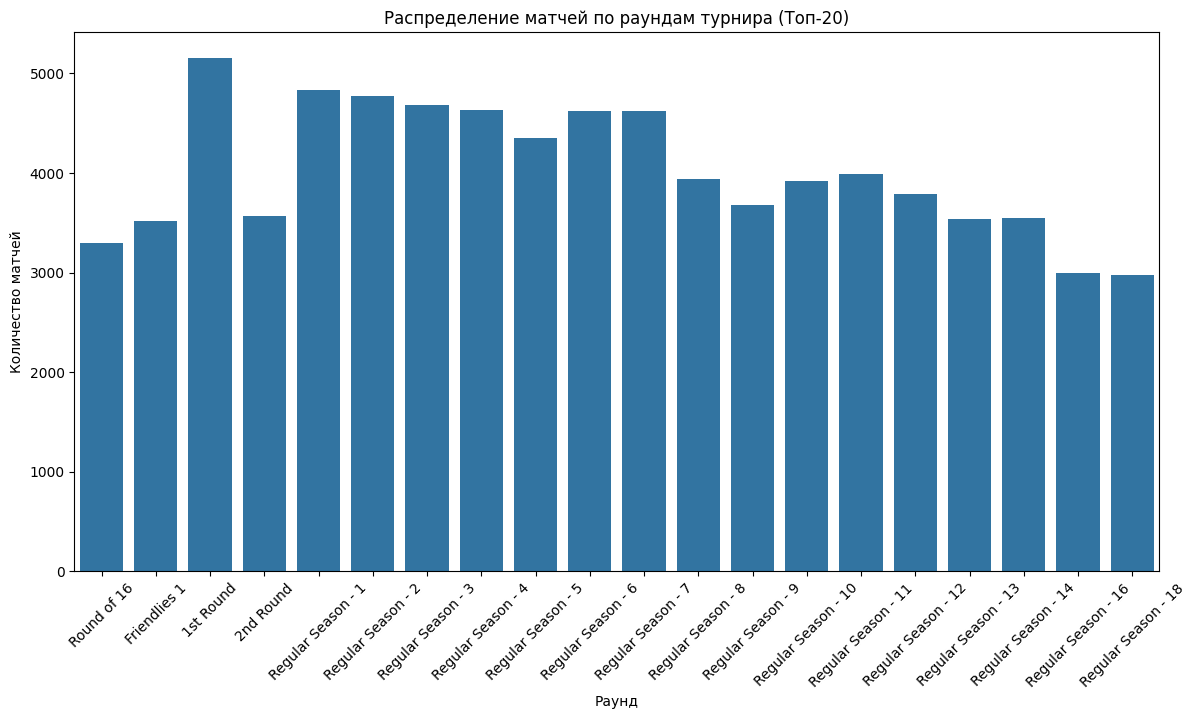

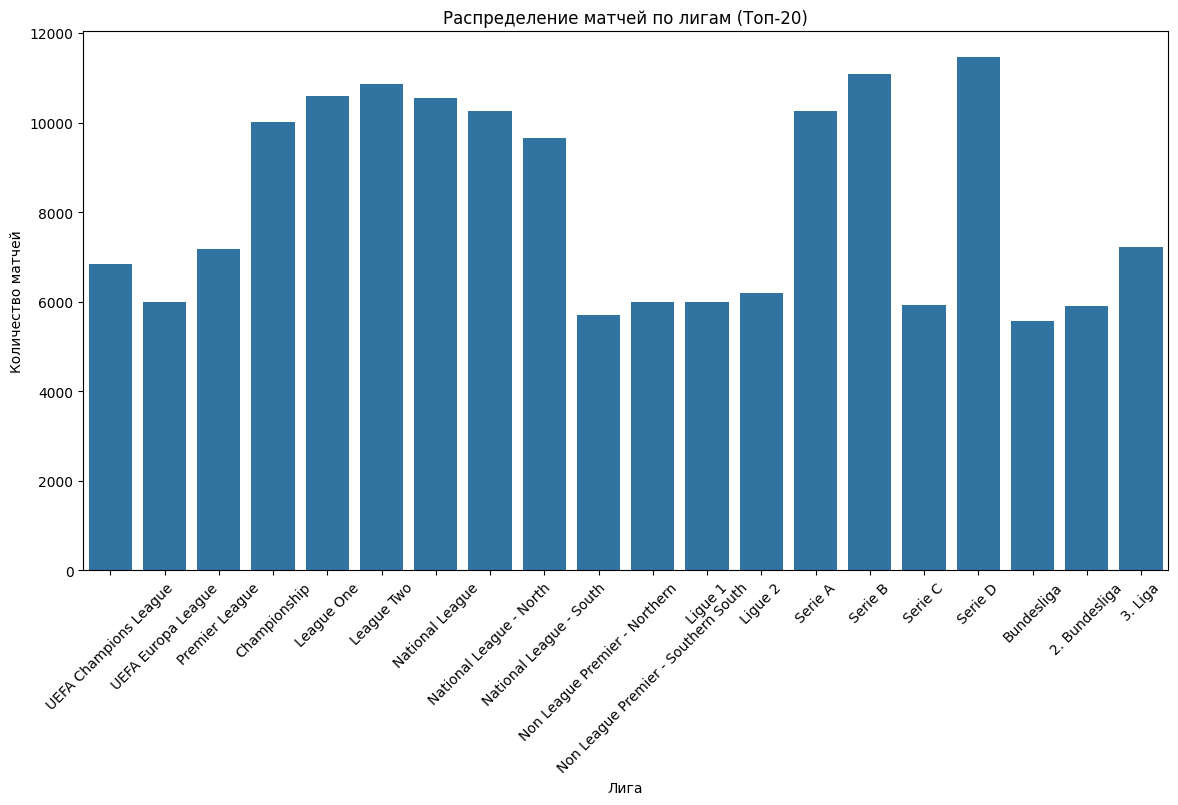

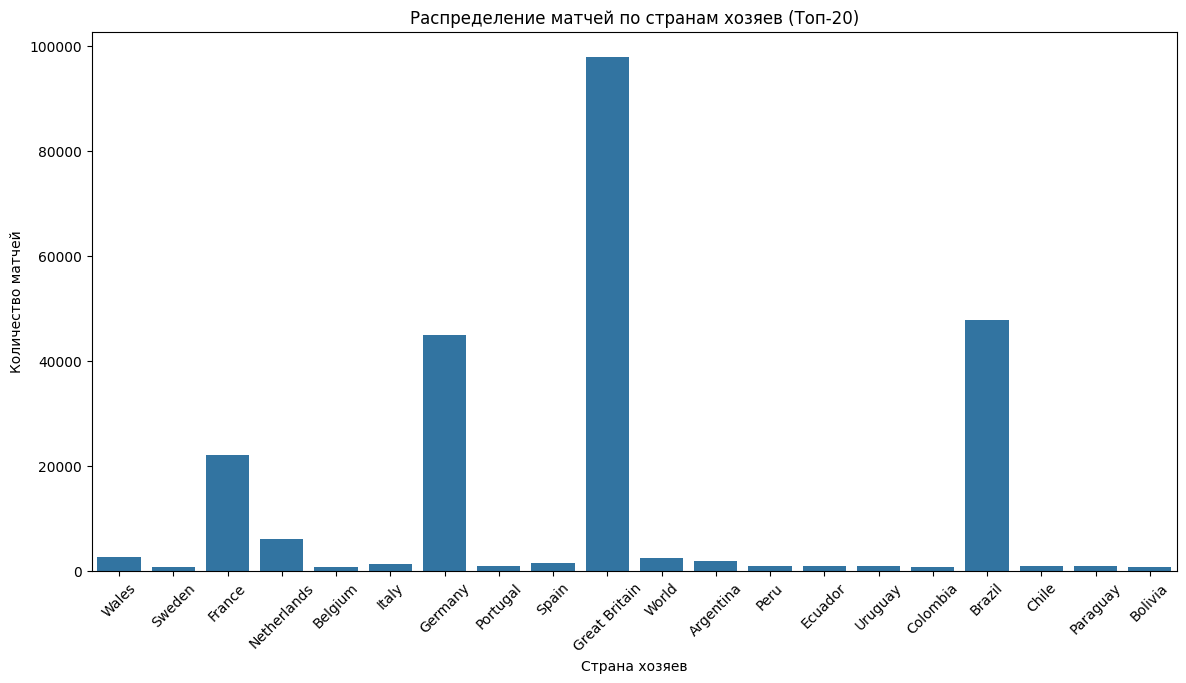

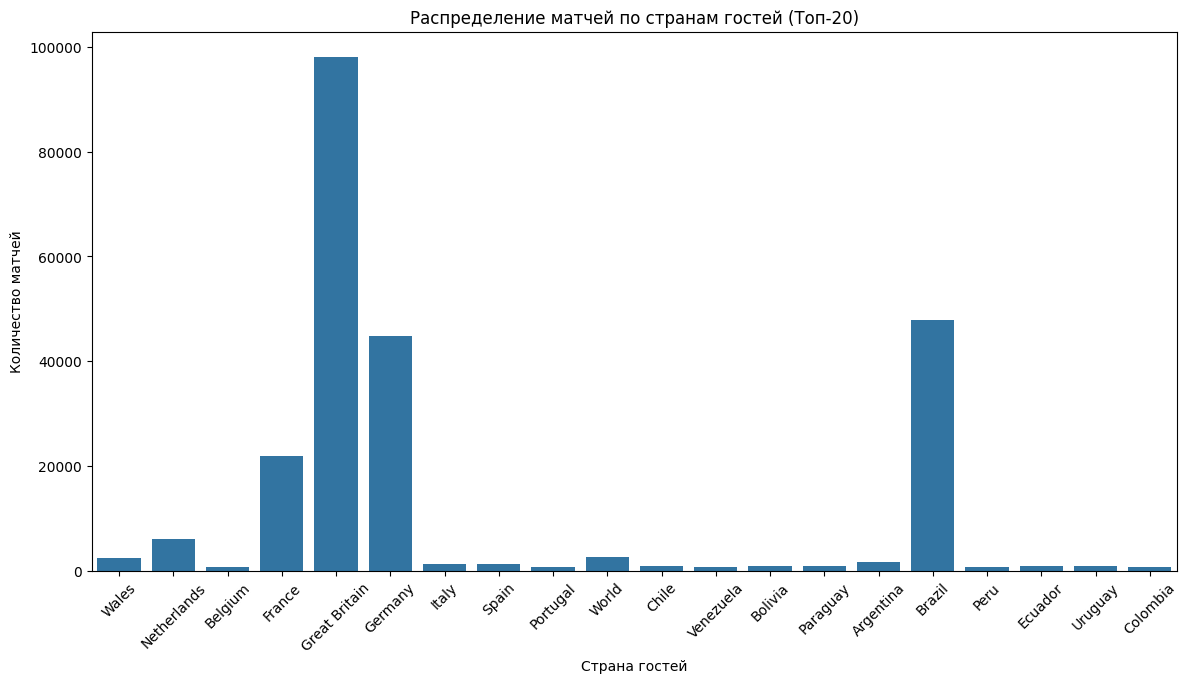

In [ ]:
df = pd.read_csv('sstats_data_normal-20251104_100000.csv')

top_20_rounds = df['roundName'].value_counts().head(20).index
plt.figure(figsize=(14, 7))
sns.countplot(x='roundName', data=df[df['roundName'].isin(top_20_rounds)])
plt.title('Распределение матчей по раундам турнира (Топ-20)')
plt.xlabel('Раунд')
plt.ylabel('Количество матчей')
plt.xticks(rotation=45)
plt.show()

top_20_leagues = df['leagueName'].value_counts().head(20).index
plt.figure(figsize=(14, 7))
sns.countplot(x='leagueName', data=df[df['leagueName'].isin(top_20_leagues)])
plt.title('Распределение матчей по лигам (Топ-20)')
plt.xlabel('Лига')
plt.ylabel('Количество матчей')
plt.xticks(rotation=45)
plt.show()

top_20_home_countries = df['homeTeamCountry'].value_counts().head(20).index
plt.figure(figsize=(14, 7))
sns.countplot(x='homeTeamCountry', data=df[df['homeTeamCountry'].isin(top_20_home_countries)])
plt.title('Распределение матчей по странам хозяев (Топ-20)')
plt.xlabel('Страна хозяев')
plt.ylabel('Количество матчей')
plt.xticks(rotation=45)
plt.show()

top_20_away_countries = df['awayTeamCountry'].value_counts().head(20).index
plt.figure(figsize=(14, 7))
sns.countplot(x='awayTeamCountry', data=df[df['awayTeamCountry'].isin(top_20_away_countries)])
plt.title('Распределение матчей по странам гостей (Топ-20)')
plt.xlabel('Страна гостей')
plt.ylabel('Количество матчей')
plt.xticks(rotation=45)
plt.show()

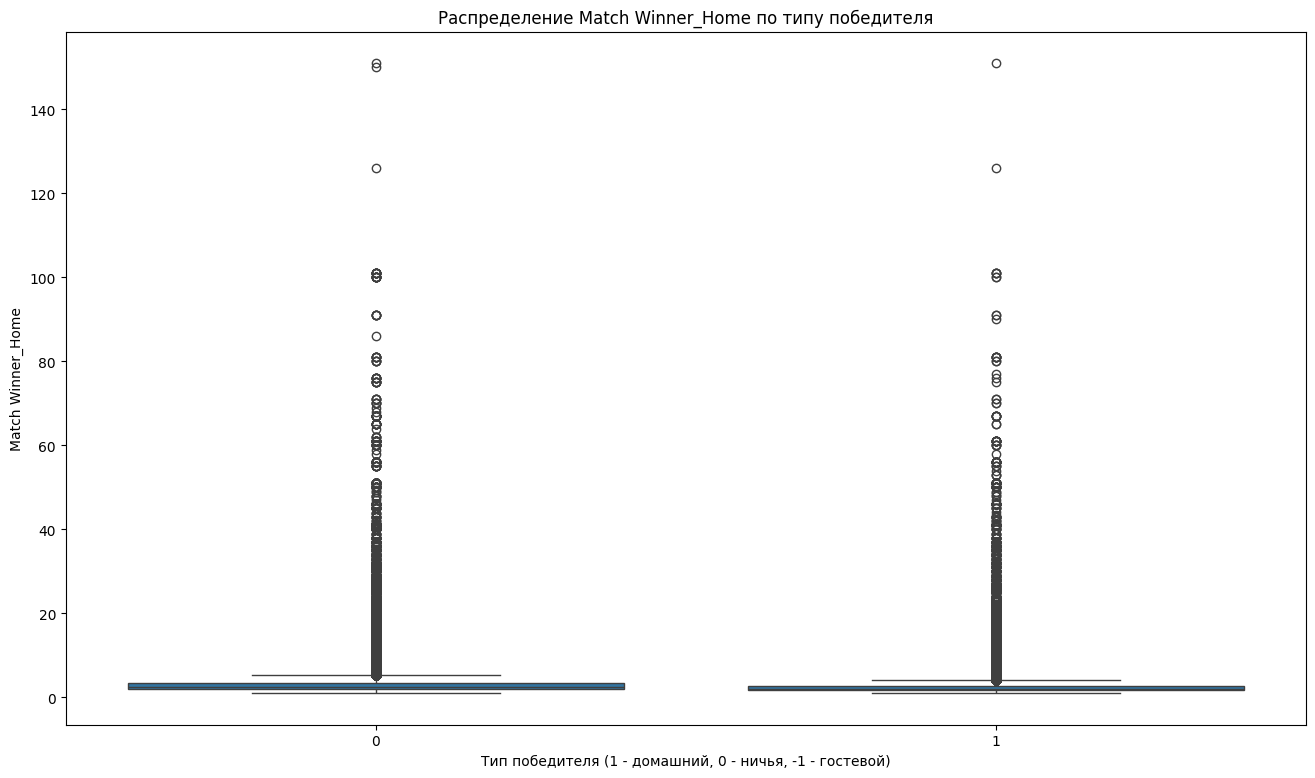

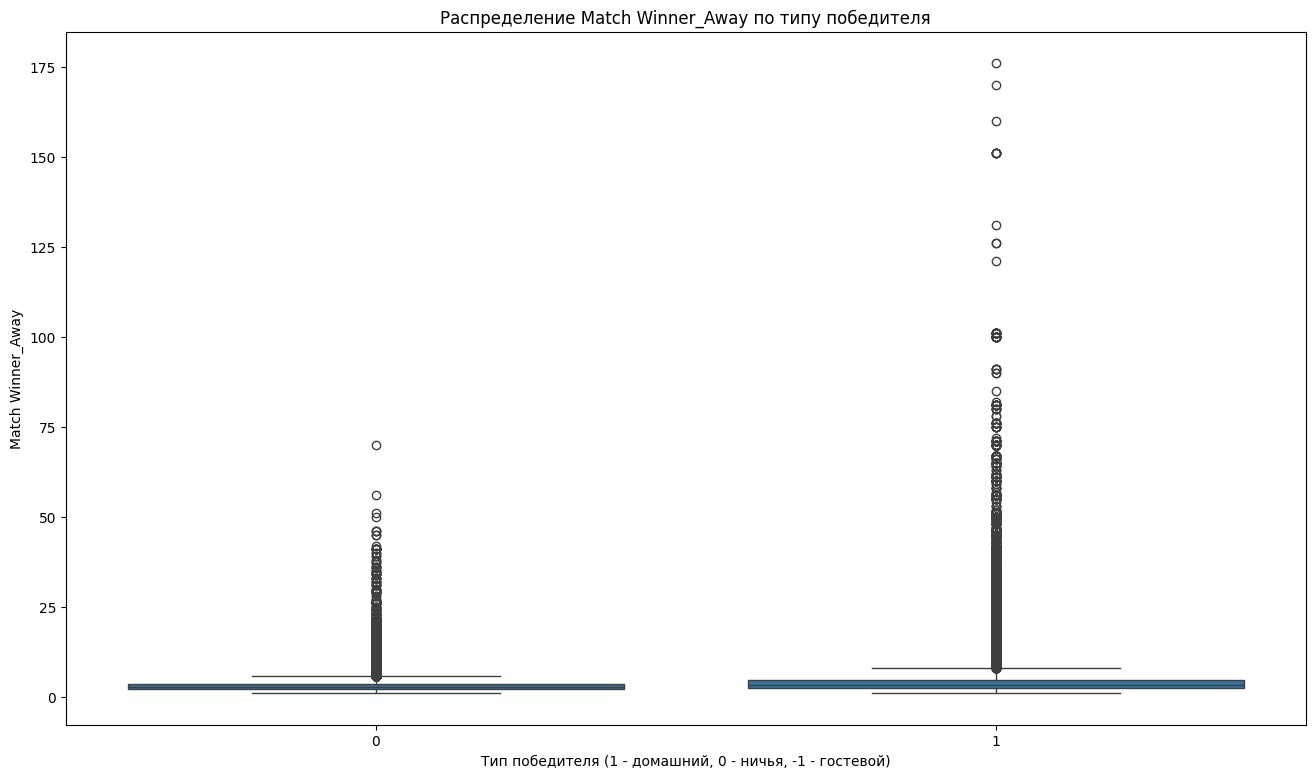

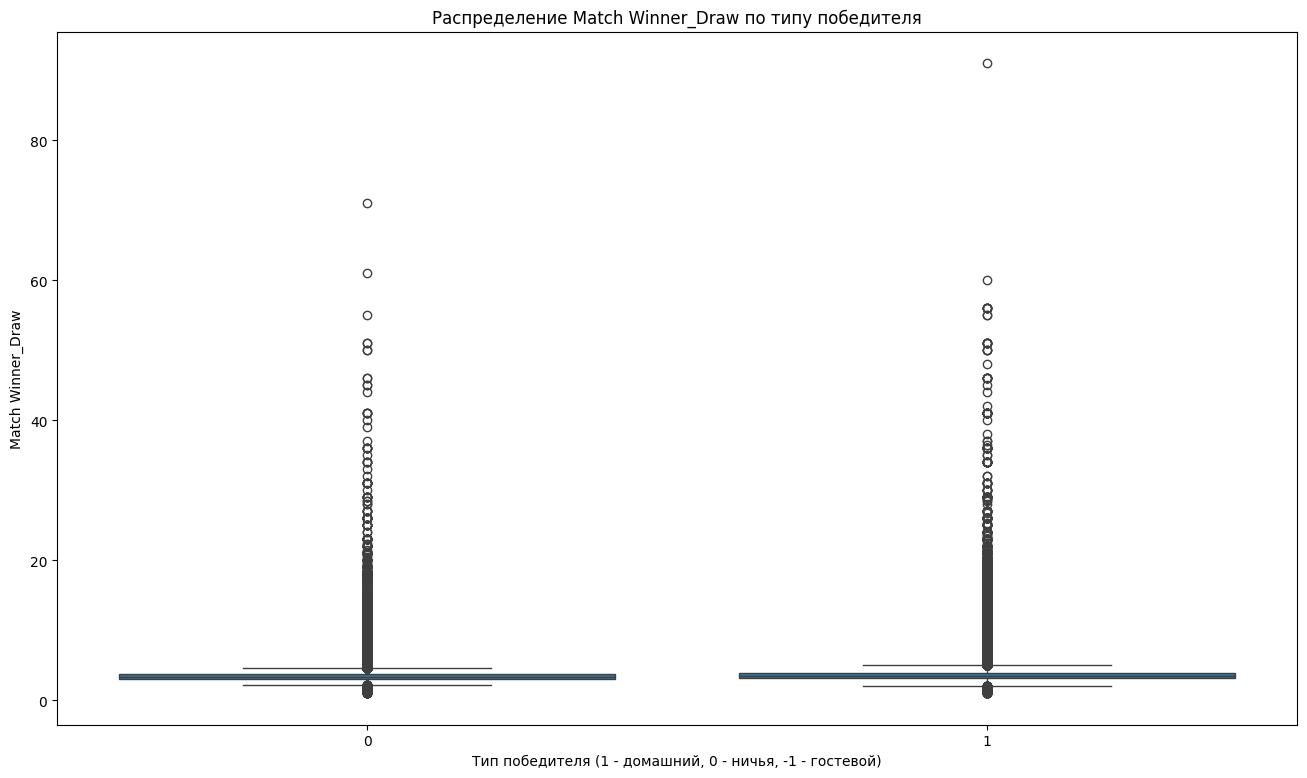

In [ ]:
def map_home_result_to_winner(home_result):
    if home_result > 0:
        return 1
    elif home_result == 0:
        return 0
    else:
        return -1

df['winner_numeric'] = df['homeResult'].apply(map_home_result_to_winner)

plt.figure(figsize=(16, 9))
sns.boxplot(x='winner_numeric', y='Match Winner_Home', data=df)
plt.title('Распределение Match Winner_Home по типу победителя')
plt.xlabel('Тип победителя (1 - домашний, 0 - ничья, -1 - гостевой)')
plt.ylabel('Match Winner_Home')
plt.show()

plt.figure(figsize=(16, 9))
sns.boxplot(x='winner_numeric', y='Match Winner_Away', data=df)
plt.title('Распределение Match Winner_Away по типу победителя')
plt.xlabel('Тип победителя (1 - домашний, 0 - ничья, -1 - гостевой)')
plt.ylabel('Match Winner_Away')
plt.show()

plt.figure(figsize=(16, 9))
sns.boxplot(x='winner_numeric', y='Match Winner_Draw', data=df)
plt.title('Распределение Match Winner_Draw по типу победителя')
plt.xlabel('Тип победителя (1 - домашний, 0 - ничья, -1 - гостевой)')
plt.ylabel('Match Winner_Draw')
plt.show()

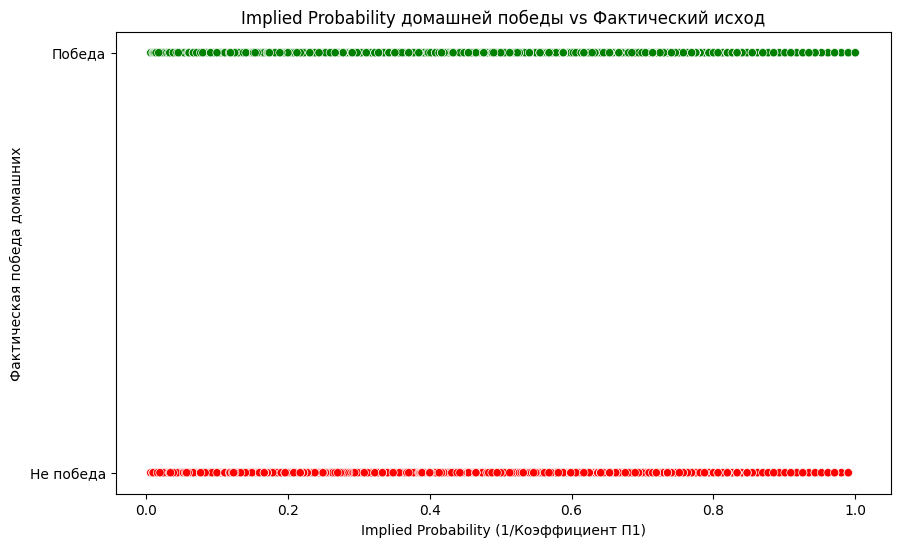

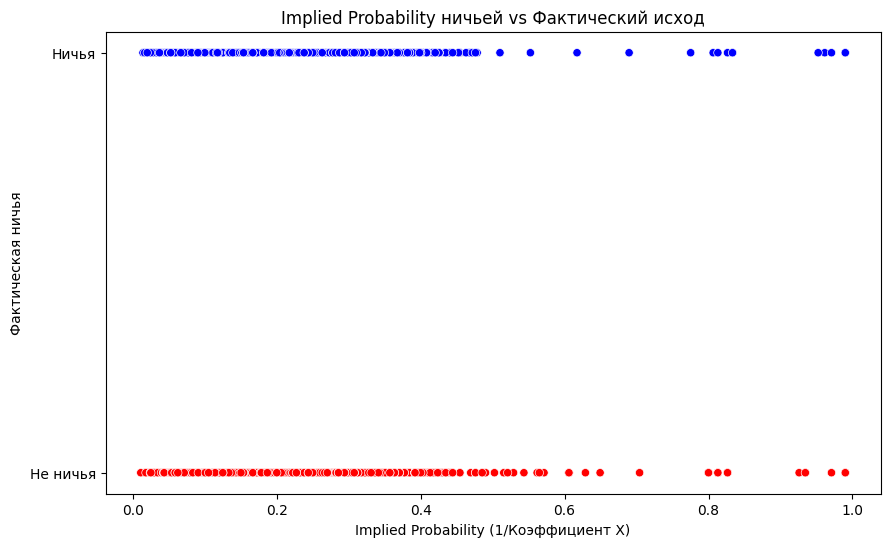

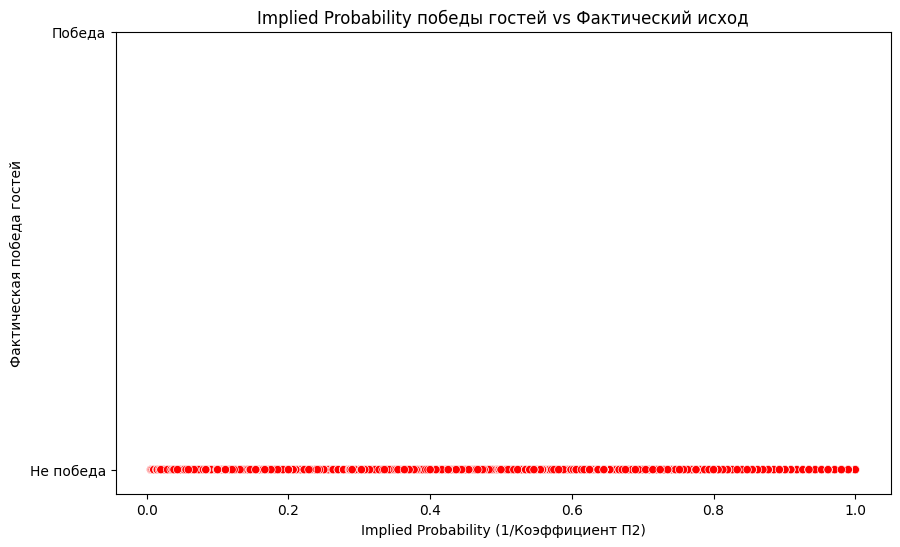

In [ ]:
df['implied_home'] = 1 / df['Match Winner_Home']
df['implied_draw'] = 1 / df['Match Winner_Draw']
df['implied_away'] = 1 / df['Match Winner_Away']

if 'winner_numeric' not in df.columns:
    conditions = [
        df['homeResult'] > df['awayResult'],
        df['homeResult'] == df['awayResult'],
        df['homeResult'] < df['awayResult']
    ]
    choices = [1, 0, -1]
    df['winner_numeric'] = np.select(conditions, choices, default=np.nan)

df['home_win_binary'] = (df['winner_numeric'] == 1).astype(int)
df['draw_binary'] = (df['winner_numeric'] == 0).astype(int)
df['away_win_binary'] = (df['winner_numeric'] == -1).astype(int)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x='implied_home',
                y='home_win_binary',
                hue='home_win_binary',
                palette={0: 'red', 1: 'green'},
                legend=None)
plt.title('Implied Probability домашней победы vs Фактический исход')
plt.xlabel('Implied Probability (1/Коэффициент П1)')
plt.ylabel('Фактическая победа домашних')
plt.yticks([0, 1], ['Не победа', 'Победа'])
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='implied_draw', y='draw_binary', hue='draw_binary', palette={0: 'red', 1: 'blue'}, legend=None)
plt.title('Implied Probability ничьей vs Фактический исход')
plt.xlabel('Implied Probability (1/Коэффициент Х)')
plt.ylabel('Фактическая ничья')
plt.yticks([0, 1], ['Не ничья', 'Ничья'])
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x='implied_away',
                y='away_win_binary',
                hue='away_win_binary',
                palette={0: 'red', 1: 'purple'},
                legend=None)
plt.title('Implied Probability победы гостей vs Фактический исход')
plt.xlabel('Implied Probability (1/Коэффициент П2)')
plt.ylabel('Фактическая победа гостей')
plt.yticks([0, 1], ['Не победа', 'Победа'])
plt.show()

In [ ]:
print(df['Match Winner_Away'].dtype)

print(df['Match Winner_Away'].isnull().sum())

print(df[['Match Winner_Away']].head())

float64
0
   Match Winner_Away
0               1.45
1               1.44
2               1.36
3               1.45
4               1.44


In [ ]:
print(df.columns)

Index(['id', 'bookmakerName', 'Match Winner_Home', 'Match Winner_Draw',
       'Match Winner_Away', 'date', 'dateUtc', 'status', 'statusName',
       'elapsed', 'homeResult', 'awayResult', 'homeHTResult', 'awayHTResult',
       'homeFTResult', 'awayFTResult', 'roundName', 'extraMinutes',
       'homeTeamName', 'homeTeamCountry', 'awayTeamName', 'awayTeamCountry',
       'leagueName', 'leagueCountry', 'winner_numeric', 'implied_home',
       'implied_draw', 'implied_away', 'home_win_binary', 'draw_binary',
       'away_win_binary'],
      dtype='object')


# ***7.2***

In [ ]:

# бинарные признаки
df['home_win'] = (df['homeResult'] > df['awayResult']).astype(int)
df['away_win'] = (df['homeResult'] < df['awayResult']).astype(int)

all_teams_data = []

# домашние матчи
home_matches = df[['homeTeamName', 'home_win']].copy()
home_matches.columns = ['team', 'win']
home_matches['is_home'] = True

# гостевые
away_matches = df[['awayTeamName', 'away_win']].copy()
away_matches.columns = ['team', 'win']
away_matches['is_home'] = False

all_matches = pd.concat([home_matches, away_matches], ignore_index=True)

# Рассчитываем статистику побед для каждой команды
team_stats = all_matches.groupby('team').agg({
    'win': ['count', 'sum'],
    'is_home': lambda x: (x == True).sum()
}).round(2)

team_stats.columns = ['total_matches', 'total_wins', 'home_matches']
team_stats = team_stats.reset_index()

# % побед
team_stats['win_rate'] = (team_stats['total_wins'] / team_stats['total_matches'] * 100).round(2)
team_stats = team_stats[team_stats['total_matches'] >= 5]

N = 10
team_stats = team_stats.sort_values('win_rate', ascending=False)

team_stats['strength_group'] = 'средние'
team_stats.loc[team_stats.head(N).index, 'strength_group'] = 'сильные'
team_stats.loc[team_stats.tail(N).index, 'strength_group'] = 'слабые'

home_std = df.groupby('homeTeamName')['Match Winner_Home'].std().reset_index()
away_std = df.groupby('awayTeamName')['Match Winner_Away'].std().reset_index()

home_std.columns = ['team', 'home_std']
away_std.columns = ['team', 'away_std']

std_data = home_std.merge(away_std, on='team', how='outer')
std_data['avg_std'] = std_data[['home_std', 'away_std']].mean(axis=1)

final_data = team_stats.merge(std_data, on='team', how='inner')

# анализ стабильности
strength_analysis = final_data.groupby('strength_group').agg({
    'avg_std': ['mean', 'std'],
    'win_rate': 'mean',
    'team': 'count'
}).round(3)


print(f"\nРаспределение команд по группам:")
print(f"Сильные команды (топ-{N}): {len(final_data[final_data['strength_group'] == 'сильные'])}")
print(f"Средние команды: {len(final_data[final_data['strength_group'] == 'средние'])}")
print(f"Слабые команды (нижние {N}): {len(final_data[final_data['strength_group'] == 'слабые'])}")

print(f"\nСредний процент побед по группам:")
print(f"Сильные команды: {final_data[final_data['strength_group'] == 'сильные']['win_rate'].mean():.1f}%")
print(f"Средние команды: {final_data[final_data['strength_group'] == 'средние']['win_rate'].mean():.1f}%")
print(f"Слабые команды: {final_data[final_data['strength_group'] == 'слабые']['win_rate'].mean():.1f}%")

print(f"\nСреднее стандартное отклонение коэффициентов по группам:")
print(f"Сильные команды: {final_data[final_data['strength_group'] == 'сильные']['avg_std'].mean():.3f}")
print(f"Средние команды: {final_data[final_data['strength_group'] == 'средние']['avg_std'].mean():.3f}")
print(f"Слабые команды: {final_data[final_data['strength_group'] == 'слабые']['avg_std'].mean():.3f}")

strong_std = final_data[final_data['strength_group'] == 'сильные']['avg_std'].mean()
weak_std = final_data[final_data['strength_group'] == 'слабые']['avg_std'].mean()

print("Гипотеза подтверждена: сильные команды имеют более стабильные коэффициенты")
print(f"Разница: {weak_std - strong_std:.3f} (меньше стандартное отклонение у сильных команд)")



Распределение команд по группам:
Сильные команды (топ-10): 10
Средние команды: 4462
Слабые команды (нижние 10): 10

Средний процент побед по группам:
Сильные команды: 100.0%
Средние команды: 31.5%
Слабые команды: 0.0%

Среднее стандартное отклонение коэффициентов по группам:
Сильные команды: 0.206
Средние команды: 1.929
Слабые команды: 0.944
Гипотеза подтверждена: сильные команды имеют более стабильные коэффициенты
Разница: 0.739 (меньше стандартное отклонение у сильных команд)


# **7.2**

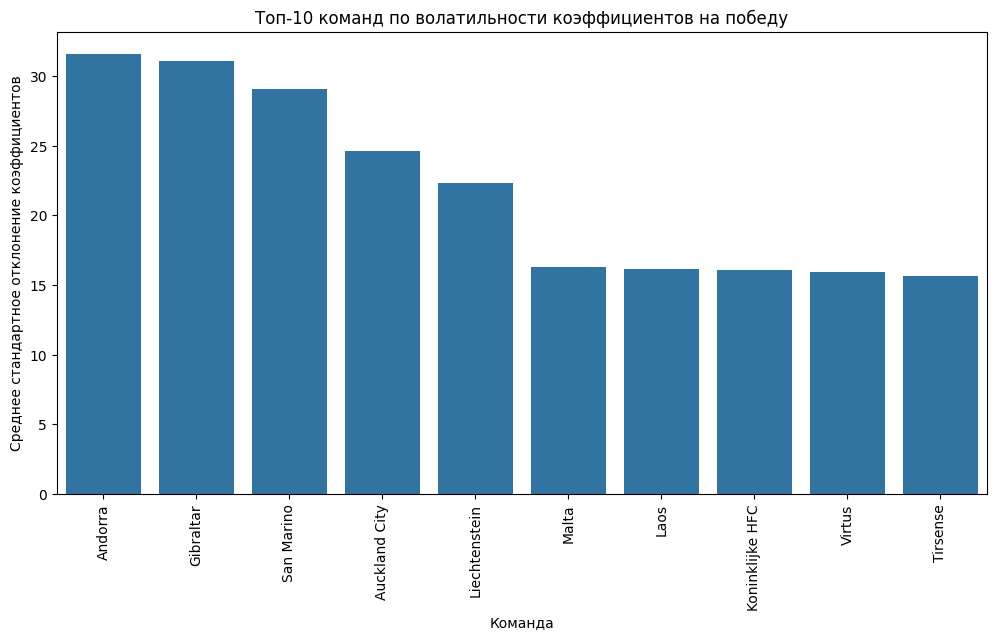

In [ ]:
home_std = df.groupby('homeTeamName')['Match Winner_Home'].std().reset_index(name='Home_Winner_Std')
away_std = df.groupby('awayTeamName')['Match Winner_Away'].std().reset_index(name='Away_Winner_Std')

std_data = pd.merge(home_std, away_std, left_on='homeTeamName', right_on='awayTeamName', how='outer')

std_data['Average_Std'] = (std_data['Home_Winner_Std'] + std_data['Away_Winner_Std']) / 2

plt.figure(figsize=(12,6))
sns.barplot(x='homeTeamName', y='Average_Std', data=std_data.sort_values('Average_Std', ascending=False).head(10))
plt.xticks(rotation=90)
plt.title('Топ-10 команд по волатильности коэффициентов на победу')
plt.xlabel('Команда')
plt.ylabel('Среднее стандартное отклонение коэффициентов')
plt.show()

# **7.3**

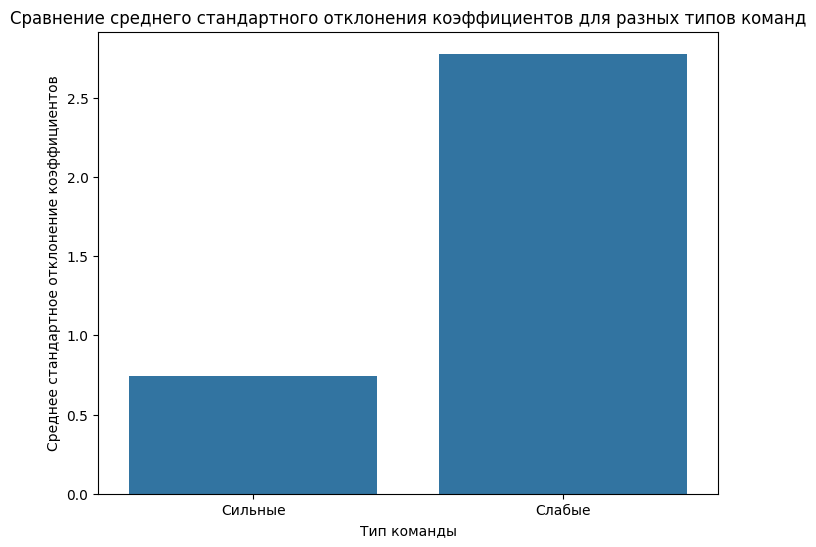

In [ ]:
home_std = df.groupby('homeTeamName')['Match Winner_Home'].std().reset_index(name='Home_Winner_Std')
away_std = df.groupby('awayTeamName')['Match Winner_Away'].std().reset_index(name='Away_Winner_Std')

std_data = pd.merge(home_std, away_std, left_on='homeTeamName', right_on='awayTeamName', how='outer')

std_data['Average_Std'] = (std_data['Home_Winner_Std'] + std_data['Away_Winner_Std']) / 2

median_std = std_data['Average_Std'].median()

std_data['Team_Strength'] = std_data['Average_Std'].apply(
    lambda x: 'Сильные' if x < median_std else ('Средние' if x == median_std else 'Слабые')
)

grouped_std = std_data.groupby('Team_Strength')['Average_Std'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='Team_Strength', y='Average_Std', data=grouped_std)
plt.title('Сравнение среднего стандартного отклонения коэффициентов для разных типов команд')
plt.xlabel('Тип команды')
plt.ylabel('Среднее стандартное отклонение коэффициентов')
plt.show()

# **7.4**

/tmp/ipython-input-574402373.py:40: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(home_data_strong, shade=True, color='blue', label='Домашние')
/tmp/ipython-input-574402373.py:41: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(away_data_strong, shade=True, color='red', label='Гостевые')


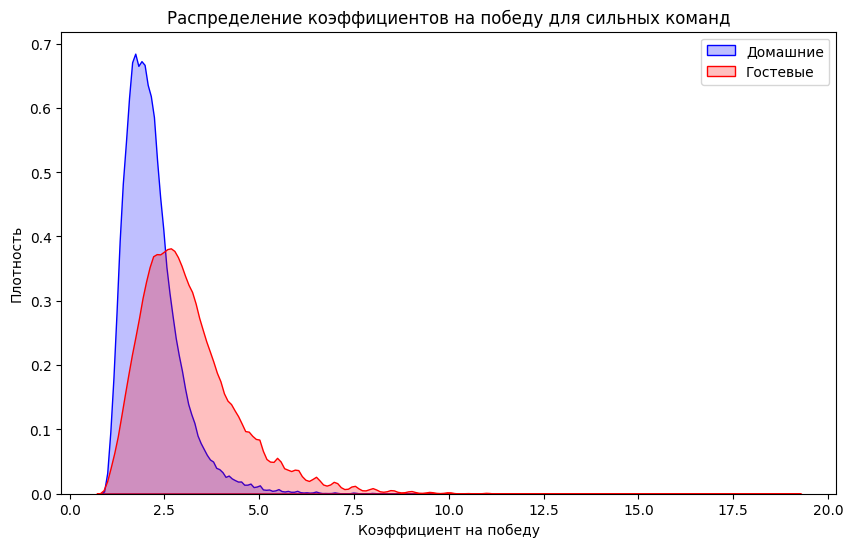

/tmp/ipython-input-574402373.py:54: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(home_data_weak, shade=True, color='blue', label='Домашние')
/tmp/ipython-input-574402373.py:55: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(away_data_weak, shade=True, color='red', label='Гостевые')


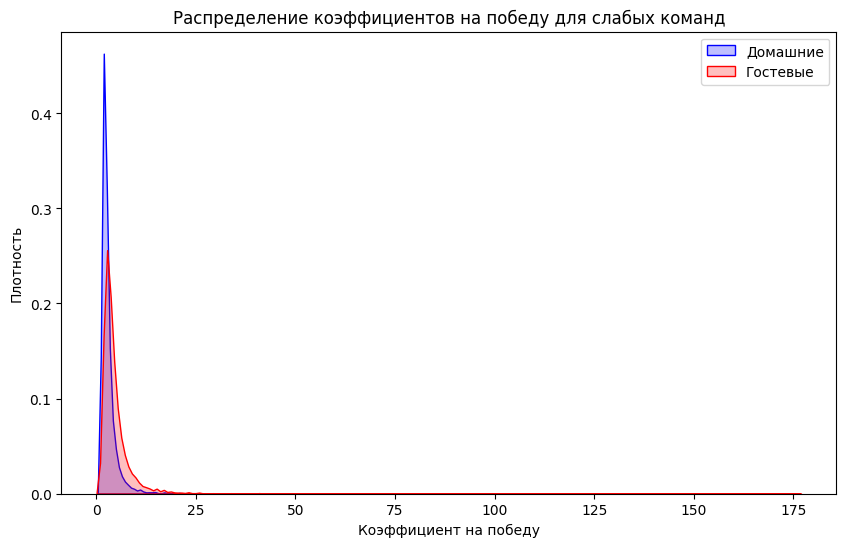

In [ ]:
# делитим пропуски
df = df.dropna(subset=['Match Winner_Home', 'Match Winner_Away'])

# стандартное отклонение
home_std = df.groupby('homeTeamName')['Match Winner_Home'].std().reset_index(name='Home_Winner_Std')
away_std = df.groupby('awayTeamName')['Match Winner_Away'].std().reset_index(name='Away_Winner_Std')

std_data = pd.merge(home_std, away_std, left_on='homeTeamName', right_on='awayTeamName', how='inner')
std_data = std_data.rename(columns={'homeTeamName': 'TeamName'})
std_data = std_data[['TeamName', 'Home_Winner_Std', 'Away_Winner_Std']]

# среднее ст. откл.
std_data['Average_Std'] = (std_data['Home_Winner_Std'] + std_data['Away_Winner_Std']) / 2

std_data = std_data.dropna(subset=['Average_Std'])

median_std = std_data['Average_Std'].median()

def categorize_team_strength(x):
    if x < median_std:
        return 'Сильные'
    elif x == median_std:
        return 'Средние'
    else:
        return 'Слабые'

std_data['Team_Strength'] = std_data['Average_Std'].apply(categorize_team_strength)

# списки команд
strong_teams = std_data[std_data['Team_Strength'] == 'Сильные']['TeamName'].tolist()
average_teams = std_data[std_data['Team_Strength'] == 'Средние']['TeamName'].tolist()
weak_teams = std_data[std_data['Team_Strength'] == 'Слабые']['TeamName'].tolist()

# график для сильных
home_data_strong = df[df['homeTeamName'].isin(strong_teams)]['Match Winner_Home'].dropna()
away_data_strong = df[df['awayTeamName'].isin(strong_teams)]['Match Winner_Away'].dropna()

if len(home_data_strong) > 0 and len(away_data_strong) > 0:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(home_data_strong, shade=True, color='blue', label='Домашние')
    sns.kdeplot(away_data_strong, shade=True, color='red', label='Гостевые')
    plt.title('Распределение коэффициентов на победу для сильных команд')
    plt.xlabel('Коэффициент на победу')
    plt.ylabel('Плотность')
    plt.legend()
    plt.show()

# график для слабых команд
home_data_weak = df[df['homeTeamName'].isin(weak_teams)]['Match Winner_Home'].dropna()
away_data_weak = df[df['awayTeamName'].isin(weak_teams)]['Match Winner_Away'].dropna()

if len(home_data_weak) > 0 and len(away_data_weak) > 0:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(home_data_weak, shade=True, color='blue', label='Домашние')
    sns.kdeplot(away_data_weak, shade=True, color='red', label='Гостевые')
    plt.title('Распределение коэффициентов на победу для слабых команд')
    plt.xlabel('Коэффициент на победу')
    plt.ylabel('Плотность')
    plt.legend()
    plt.show()

# **7.5**

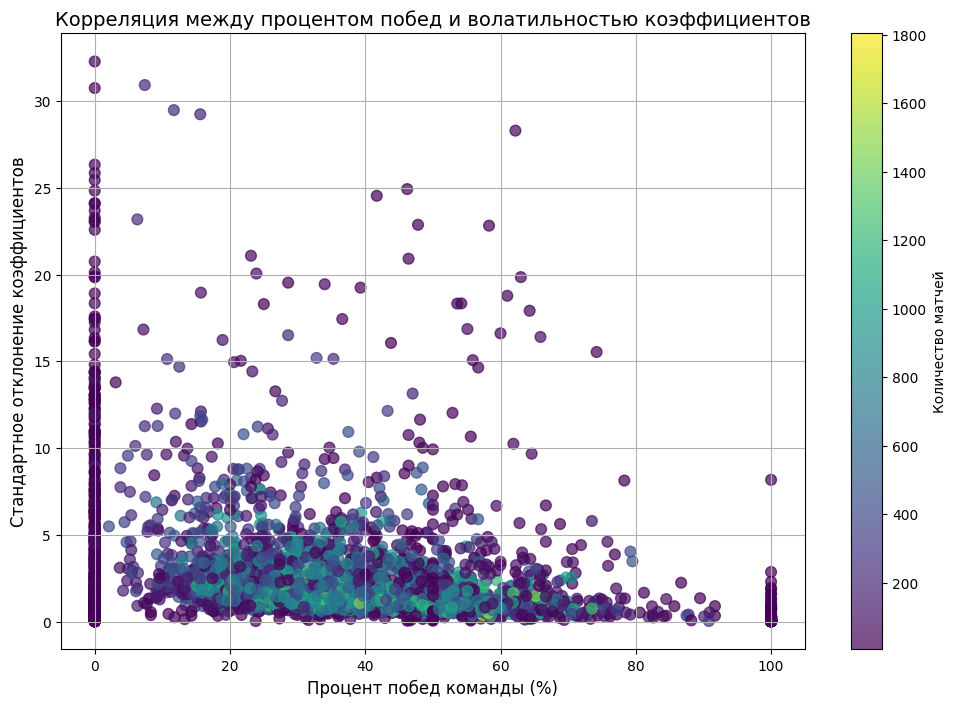

Корреляция между процентом побед и std коэффициентов: -0.175

Топ-10 команд по проценту побед:
                  team  win_rate_percent  odds_std  total_matches
14              2Drots             100.0  0.045617              7
43      ADO Den Haag W             100.0  0.020111             10
51           AFC Emley             100.0  0.033282             13
132             Ajax W             100.0  0.022039              8
189        Algeria U20             100.0  0.037203             12
230              Amora             100.0  0.233365             14
252    Annapolis Blues             100.0  0.035929             12
262          Antoniano             100.0  0.341836             12
331       Athletic U19             100.0  0.247920             22
354  Atlético Baleares             100.0  0.141879             12


In [ ]:
matches_data = []

home_matches = df[['homeTeamName', 'homeResult', 'awayResult', 'Match Winner_Home']].copy()
home_matches.columns = ['team', 'goals_for', 'goals_against', 'odds']
home_matches['is_home'] = True
home_matches['is_win'] = home_matches['goals_for'] > home_matches['goals_against']

away_matches = df[['awayTeamName', 'awayResult', 'homeResult', 'Match Winner_Away']].copy()
away_matches.columns = ['team', 'goals_for', 'goals_against', 'odds']
away_matches['is_home'] = False
away_matches['is_win'] = away_matches['goals_for'] > away_matches['goals_against']

all_matches = pd.concat([home_matches, away_matches], ignore_index=True)

team_win_rates = all_matches.groupby('team').agg({'is_win': ['count', 'mean']}).round(3)
team_win_rates.columns = ['total_matches', 'win_rate']
team_win_rates = team_win_rates.reset_index()
team_win_rates['win_rate_percent'] = team_win_rates['win_rate'] * 100

team_odds_std = all_matches.groupby('team')['odds'].std().reset_index()
team_odds_std.columns = ['team', 'odds_std']

team_stats = team_win_rates.merge(team_odds_std, on='team', how='inner')

team_stats = team_stats[team_stats['total_matches'] >= 5]

plt.figure(figsize=(12, 8))

scatter = plt.scatter(team_stats['win_rate_percent'],
                     team_stats['odds_std'],
                     c=team_stats['total_matches'],
                     cmap='viridis',
                     alpha=0.7,
                     s=60)

plt.colorbar(scatter, label='Количество матчей')
plt.xlabel('Процент побед команды (%)', fontsize=12)
plt.ylabel('Стандартное отклонение коэффициентов', fontsize=12)
plt.title('Корреляция между процентом побед и волатильностью коэффициентов', fontsize=14)

plt.grid(True)
plt.show()

correlation = team_stats['win_rate_percent'].corr(team_stats['odds_std'])
print(f"Корреляция между процентом побед и std коэффициентов: {correlation:.3f}")

print("\nТоп-10 команд по проценту побед:")
print(team_stats.nlargest(10, 'win_rate_percent')[['team', 'win_rate_percent', 'odds_std', 'total_matches']])

# **7.6**

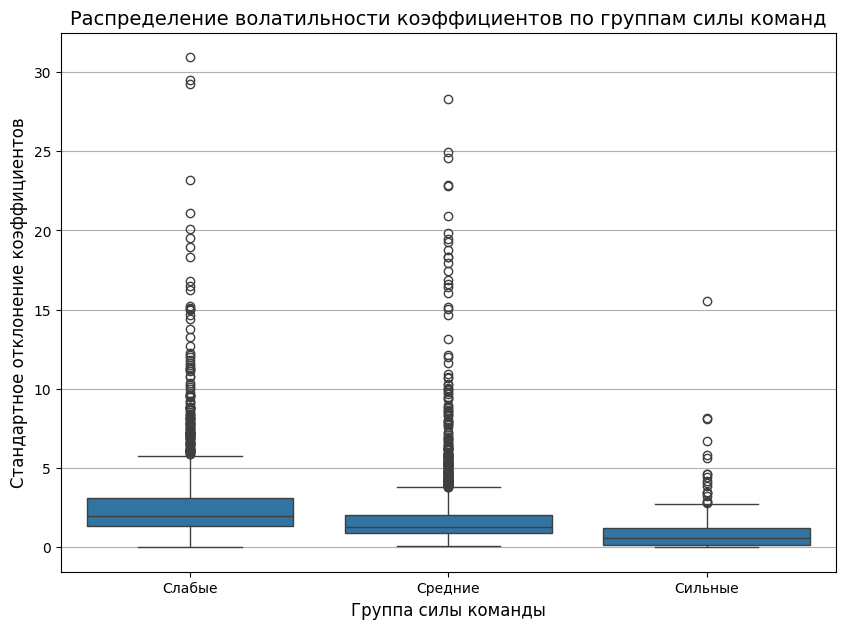

In [ ]:
matches_data = []

home_matches = df[['homeTeamName', 'homeResult', 'awayResult', 'Match Winner_Home']].copy()
home_matches.columns = ['team', 'goals_for', 'goals_against', 'odds']
home_matches['is_home'] = True
home_matches['is_win'] = home_matches['goals_for'] > home_matches['goals_against']

away_matches = df[['awayTeamName', 'awayResult', 'homeResult', 'Match Winner_Away']].copy()
away_matches.columns = ['team', 'goals_for', 'goals_against', 'odds']
away_matches['is_home'] = False
away_matches['is_win'] = away_matches['goals_for'] > away_matches['goals_against']

all_matches = pd.concat([home_matches, away_matches], ignore_index=True)

team_win_rates = all_matches.groupby('team').agg({
    'is_win': ['count', 'mean']
}).round(3)
team_win_rates.columns = ['total_matches', 'win_rate']
team_win_rates = team_win_rates.reset_index()
team_win_rates['win_rate_percent'] = team_win_rates['win_rate'] * 100

team_odds_std = all_matches.groupby('team')['odds'].std().reset_index()
team_odds_std.columns = ['team', 'odds_std']

team_stats = team_win_rates.merge(team_odds_std, on='team', how='inner')

team_stats = team_stats[team_stats['total_matches'] >= 5]

team_stats['strength_group'] = pd.cut(team_stats['win_rate_percent'],
                                     bins=[0, 33, 66, 100],
                                     labels=['Слабые', 'Средние', 'Сильные'])

plt.figure(figsize=(10, 7))

sns.boxplot(data=team_stats, x='strength_group', y='odds_std')

plt.xlabel('Группа силы команды', fontsize=12)
plt.ylabel('Стандартное отклонение коэффициентов', fontsize=12)
plt.title('Распределение волатильности коэффициентов по группам силы команд', fontsize=14)
plt.grid(True, axis='y')
plt.show()

# **7.7**

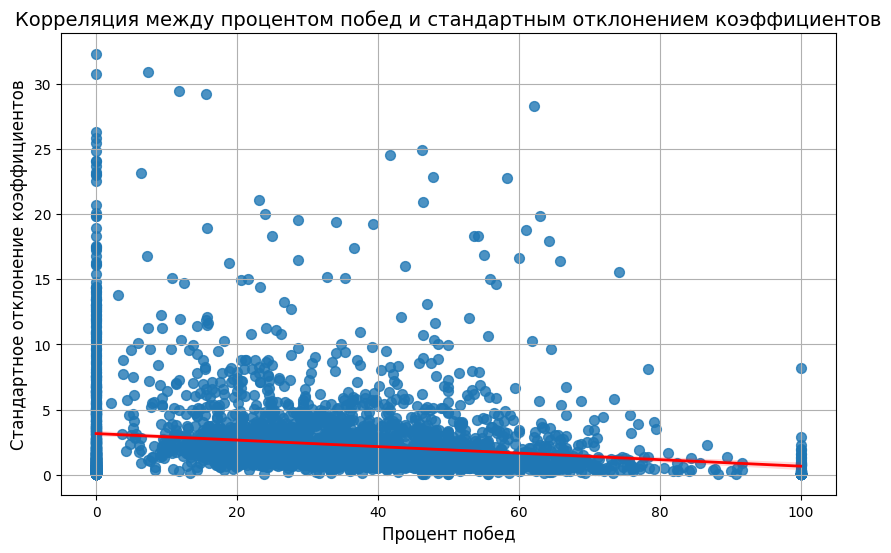

Коэффициент корреляции: -0.1745518407490733


In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='win_rate_percent', y='odds_std', data=team_stats, scatter_kws={'s': 50}, line_kws={'color': 'red', 'lw': 2})

plt.xlabel('Процент побед', fontsize=12)
plt.ylabel('Стандартное отклонение коэффициентов', fontsize=12)
plt.title('Корреляция между процентом побед и стандартным отклонением коэффициентов', fontsize=14)
plt.grid(True)

plt.show()
print(f'Коэффициент корреляции: {correlation}')

# **1.1**

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['hour_of_day'] = df['date'].dt.hour

df['day_of_week'] = df['date'].dt.dayofweek

df['month'] = df['date'].dt.month

print(df[['date', 'hour_of_day', 'day_of_week', 'month']].head(10))

                       date  hour_of_day  day_of_week  month
0 2024-07-09 15:30:00+00:00           15            1      7
1 2024-07-09 15:30:00+00:00           15            1      7
2 2024-07-09 15:30:00+00:00           15            1      7
3 2024-07-09 15:30:00+00:00           15            1      7
4 2024-07-09 15:30:00+00:00           15            1      7
5 2024-07-09 15:30:00+00:00           15            1      7
6 2024-07-09 15:30:00+00:00           15            1      7
7 2024-07-09 15:30:00+00:00           15            1      7
8 2024-07-09 15:30:00+00:00           15            1      7
9 2024-07-09 15:30:00+00:00           15            1      7


# **1.2**

In [ ]:
df['Match Winner_Home'] = pd.to_numeric(df['Match Winner_Home'], errors='coerce')
df['Match Winner_Away'] = pd.to_numeric(df['Match Winner_Away'], errors='coerce')

df['implied_probability_home'] = 1 / df['Match Winner_Home']
df['implied_probability_away'] = 1 / df['Match Winner_Away']

df['actual_home_win'] = df['homeResult'] == 'Home'
df['actual_away_win'] = df['awayResult'] == 'Away'

numeric_columns = ['implied_probability_home', 'actual_home_win',
                   'implied_probability_away', 'actual_away_win']

hour_home_error = df.groupby('hour_of_day')[numeric_columns].mean()
hour_home_error['home_error'] = hour_home_error['implied_probability_home'] - hour_home_error['actual_home_win']

hour_away_error = df.groupby('hour_of_day')[numeric_columns].mean()
hour_away_error['away_error'] = hour_away_error['implied_probability_away'] - hour_away_error['actual_away_win']

day_of_week_home_error = df.groupby('day_of_week')[numeric_columns].mean()
day_of_week_home_error['home_error'] = day_of_week_home_error['implied_probability_home'] - day_of_week_home_error['actual_home_win']

day_of_week_away_error = df.groupby('day_of_week')[numeric_columns].mean()
day_of_week_away_error['away_error'] = day_of_week_away_error['implied_probability_away'] - day_of_week_away_error['actual_away_win']

month_home_error = df.groupby('month')[numeric_columns].mean()
month_home_error['home_error'] = month_home_error['implied_probability_home'] - month_home_error['actual_home_win']

month_away_error = df.groupby('month')[numeric_columns].mean()
month_away_error['away_error'] = month_away_error['implied_probability_away'] - month_away_error['actual_away_win']

error_by_time = pd.concat([hour_home_error['home_error'], hour_away_error['away_error'],
                           day_of_week_home_error['home_error'], day_of_week_away_error['away_error'],
                           month_home_error['home_error'], month_away_error['away_error']], axis=1)

print(error_by_time)

    home_error  away_error  home_error  away_error  home_error  away_error
0     0.495163    0.294434    0.465589    0.330432         NaN         NaN
1     0.504383    0.299089    0.466071    0.344901    0.470760    0.332302
2     0.502865    0.310087    0.461333    0.355761    0.466390    0.334227
3     0.463038    0.342809    0.471730    0.339427    0.467694    0.331965
4     0.448269    0.352973    0.470820    0.338438    0.463403    0.339701
5     0.439717    0.366219    0.467682    0.337931    0.472798    0.334294
6     0.441633    0.358976    0.470133    0.329198    0.472540    0.336307
7     0.441802    0.374714         NaN         NaN    0.473884    0.336106
8     0.477047    0.341570         NaN         NaN    0.465897    0.338833
9     0.446578    0.371233         NaN         NaN    0.469478    0.336428
10    0.445155    0.357914         NaN         NaN    0.464138    0.344517
11    0.456575    0.360555         NaN         NaN    0.470377    0.336448
12    0.462382    0.35501

# **7.3**

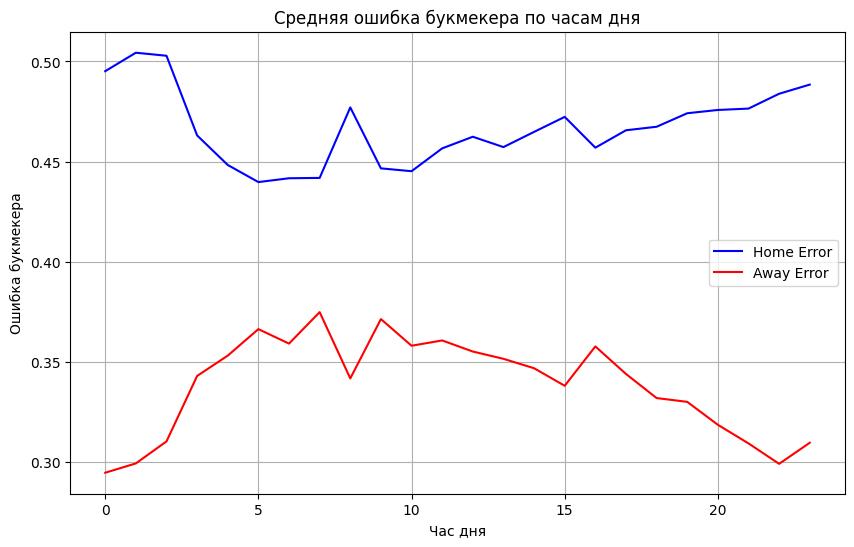

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=hour_home_error.index, y=hour_home_error['home_error'], label='Home Error', color='blue')
sns.lineplot(x=hour_away_error.index, y=hour_away_error['away_error'], label='Away Error', color='red')
plt.title('Средняя ошибка букмекера по часам дня')
plt.xlabel('Час дня')
plt.ylabel('Ошибка букмекера')
plt.legend()
plt.grid(True)
plt.show()

# **1.4**

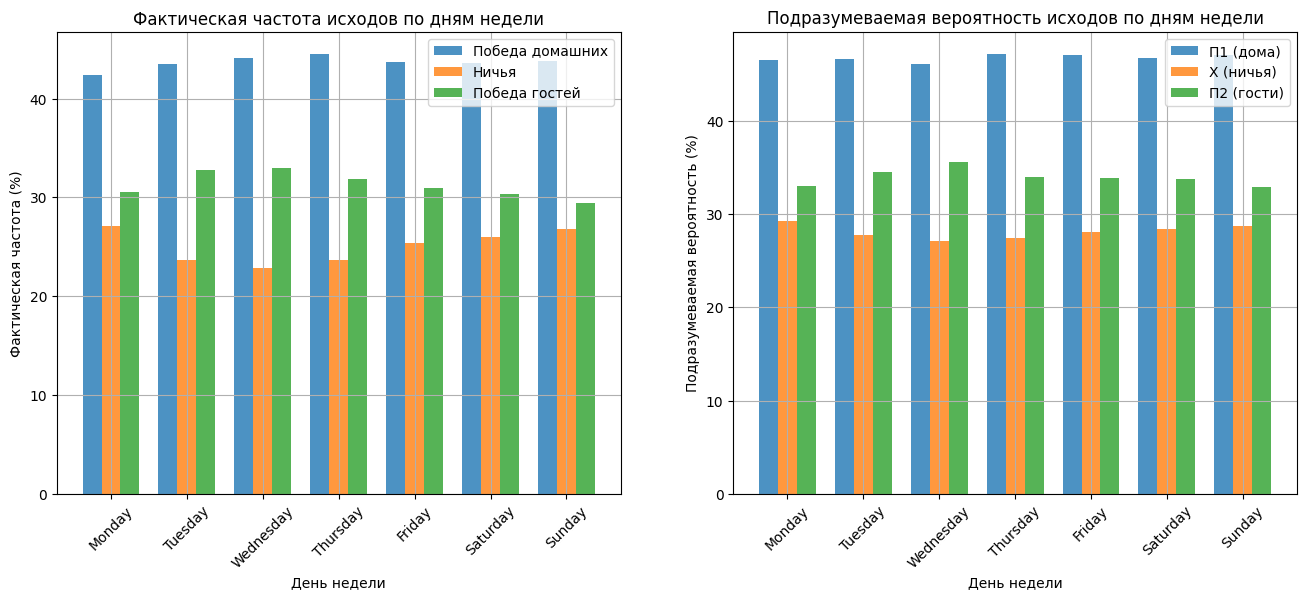

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()

df['home_win'] = (df['homeResult'] > df['awayResult']).astype(int)
df['draw'] = (df['homeResult'] == df['awayResult']).astype(int)
df['away_win'] = (df['homeResult'] < df['awayResult']).astype(int)

df['implied_home'] = 1 / df['Match Winner_Home']
df['implied_draw'] = 1 / df['Match Winner_Draw']
df['implied_away'] = 1 / df['Match Winner_Away']

day_stats = df.groupby('day_of_week').agg({
    'home_win': 'mean',
    'draw': 'mean',
    'away_win': 'mean',
    'implied_home': 'mean',
    'implied_draw': 'mean',
    'implied_away': 'mean'
}).reset_index()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats['day_of_week'] = pd.Categorical(day_stats['day_of_week'], categories=days_order, ordered=True)
day_stats = day_stats.sort_values('day_of_week')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(day_stats))
width = 0.25

ax1.bar(x - width, day_stats['home_win'] * 100, width, label='Победа домашних', alpha=0.8)
ax1.bar(x, day_stats['draw'] * 100, width, label='Ничья', alpha=0.8)
ax1.bar(x + width, day_stats['away_win'] * 100, width, label='Победа гостей', alpha=0.8)

ax1.set_xlabel('День недели')
ax1.set_ylabel('Фактическая частота (%)')
ax1.set_title('Фактическая частота исходов по дням недели')
ax1.set_xticks(x)
ax1.set_xticklabels(day_stats['day_of_week'], rotation=45)
ax1.legend()
ax1.grid(True)

ax2.bar(x - width, day_stats['implied_home'] * 100, width, label='П1 (дома)', alpha=0.8)
ax2.bar(x, day_stats['implied_draw'] * 100, width, label='Х (ничья)', alpha=0.8)
ax2.bar(x + width, day_stats['implied_away'] * 100, width, label='П2 (гости)', alpha=0.8)

ax2.set_xlabel('День недели')
ax2.set_ylabel('Подразумеваемая вероятность (%)')
ax2.set_title('Подразумеваемая вероятность исходов по дням недели')
ax2.set_xticks(x)
ax2.set_xticklabels(day_stats['day_of_week'], rotation=45)
ax2.legend()
ax2.grid(True)
plt.show()

# **1.5**

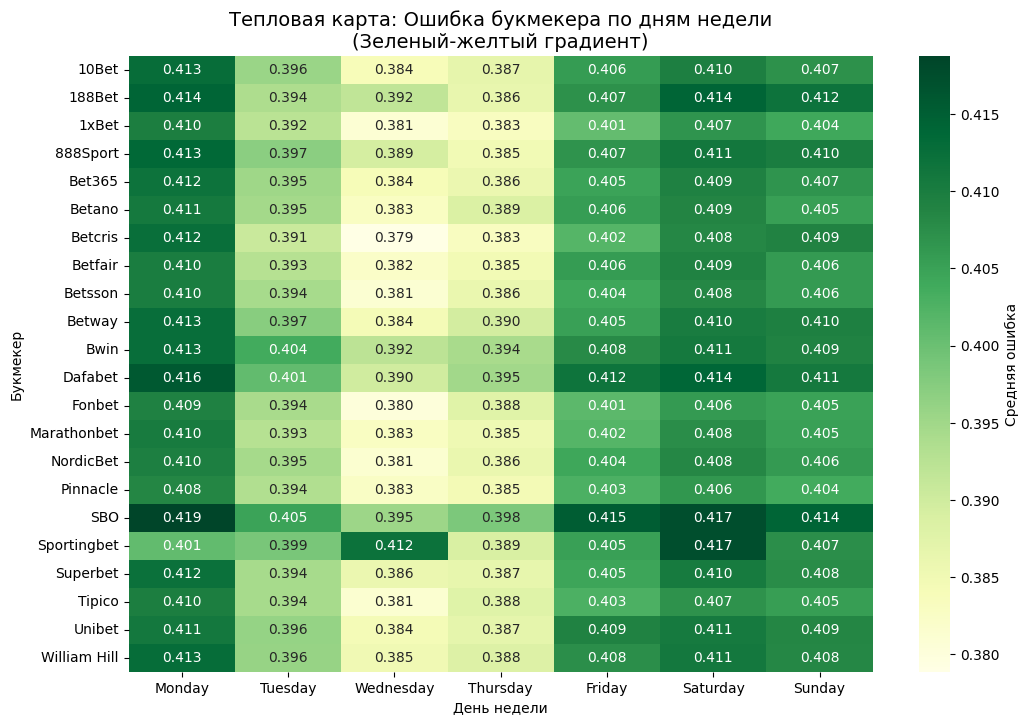

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['day_num'] = df['date'].dt.dayofweek

df['home_win'] = (df['homeResult'] > df['awayResult']).astype(int)
df['draw'] = (df['homeResult'] == df['awayResult']).astype(int)
df['away_win'] = (df['homeResult'] < df['awayResult']).astype(int)

df['implied_home'] = 1 / df['Match Winner_Home']
df['implied_draw'] = 1 / df['Match Winner_Draw']
df['implied_away'] = 1 / df['Match Winner_Away']

df['error_home'] = df['home_win'] - df['implied_home']
df['error_draw'] = df['draw'] - df['implied_draw']
df['error_away'] = df['away_win'] - df['implied_away']

df['total_error'] = (abs(df['error_home']) + abs(df['error_draw']) + abs(df['error_away'])) / 3

heatmap_data = df.groupby(['bookmakerName', 'day_of_week']).agg({
    'total_error': 'mean',
    'error_home': 'mean',
    'error_draw': 'mean',
    'error_away': 'mean'
}).reset_index()

pivot_total = heatmap_data.pivot(index='bookmakerName',
                                columns='day_of_week',
                                values='total_error')

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_total = pivot_total[days_order]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_total,
            annot=True,
            fmt='.3f',
            cmap='YlGn',
            cbar_kws={'label': 'Средняя ошибка'})

plt.title('Тепловая карта: Ошибка букмекера по дням недели\n(Зеленый-желтый градиент)', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Букмекер')
plt.show()

# **2.1**

In [ ]:
df['home_win'] = (df['homeResult'] > df['awayResult']).astype(int)
df['draw'] = (df['homeResult'] == df['awayResult']).astype(int)
df['away_win'] = (df['homeResult'] < df['awayResult']).astype(int)

league_stats = df.groupby('leagueName').agg({
    'home_win': ['count', 'mean'],
    'draw': 'mean',
    'away_win': 'mean',
    'homeTeamCountry': 'first'
}).round(4)

league_stats.columns = ['total_matches', 'home_win_rate', 'draw_rate', 'away_win_rate', 'country']
league_stats = league_stats.reset_index()

league_stats['HAI'] = ((league_stats['home_win_rate'] - league_stats['away_win_rate']) * 100).round(2)
league_stats['home_win_percent'] = (league_stats['home_win_rate'] * 100).round(2)
league_stats['away_win_percent'] = (league_stats['away_win_rate'] * 100).round(2)
league_stats['draw_percent'] = (league_stats['draw_rate'] * 100).round(2)

league_stats = league_stats[league_stats['total_matches'] >= 10]

country_stats = df.groupby('homeTeamCountry').agg({
    'home_win': ['count', 'mean'],
    'draw': 'mean',
    'away_win': 'mean'
}).round(4)

country_stats.columns = ['total_matches', 'home_win_rate', 'draw_rate', 'away_win_rate']
country_stats = country_stats.reset_index()

country_stats['HAI'] = ((country_stats['home_win_rate'] - country_stats['away_win_rate']) * 100).round(2)
country_stats['home_win_percent'] = (country_stats['home_win_rate'] * 100).round(2)
country_stats['away_win_percent'] = (country_stats['away_win_rate'] * 100).round(2)
country_stats['draw_percent'] = (country_stats['draw_rate'] * 100).round(2)

country_stats = country_stats[country_stats['total_matches'] >= 10]

overall_home_win = df['home_win'].mean() * 100
overall_away_win = df['away_win'].mean() * 100
overall_draw = df['draw'].mean() * 100
overall_HAI = overall_home_win - overall_away_win

print("ОБЩАЯ СТАТИСТИКА ПО ДАТАСЕТУ:")
print(f"Побед домашних команд: {overall_home_win:.2f}%")
print(f"Ничьих: {overall_draw:.2f}%")
print(f"Побед гостевых команд: {overall_away_win:.2f}%")
print(f"Home Advantage Index (HAI): {overall_HAI:.2f}")

ОБЩАЯ СТАТИСТИКА ПО ДАТАСЕТУ:
Побед домашних команд: 43.69%
Ничьих: 25.65%
Побед гостевых команд: 30.66%
Home Advantage Index (HAI): 13.02


# **2.2**

In [ ]:
df['home_win'] = (df['homeResult'] > df['awayResult']).astype(int)
df['draw'] = (df['homeResult'] == df['awayResult']).astype(int)
df['away_win'] = (df['homeResult'] < df['awayResult']).astype(int)

df['implied_home'] = 1 / df['Match Winner_Home']
df['implied_draw'] = 1 / df['Match Winner_Draw']
df['implied_away'] = 1 / df['Match Winner_Away']

league_analysis = df.groupby('leagueName').agg({
    'home_win': ['count', 'mean'],
    'away_win': 'mean',
    'implied_home': 'mean',
    'homeTeamCountry': 'first'
}).round(4)

league_analysis.columns = ['total_matches', 'actual_home_win', 'actual_away_win', 'implied_home_prob', 'country']
league_analysis = league_analysis.reset_index()

league_analysis['HAI'] = ((league_analysis['actual_home_win'] - league_analysis['actual_away_win']) * 100).round(2)
league_analysis['bias'] = ((league_analysis['actual_home_win'] - league_analysis['implied_home_prob']) * 100).round(2)

league_analysis = league_analysis[league_analysis['total_matches'] >= 15]

overall_actual = df['home_win'].mean()
overall_implied = df['implied_home'].mean()
overall_bias = (overall_actual - overall_implied) * 100

print("ОБЩАЯ СТАТИСТИКА:")
print(f"Фактический % домашних побед: {overall_actual*100:.2f}%")
print(f"Подразумеваемый % домашних побед: {overall_implied*100:.2f}%")
print(f"Общее смещение: {overall_bias:.2f}%")

ОБЩАЯ СТАТИСТИКА:
Фактический % домашних побед: 43.69%
Подразумеваемый % домашних побед: 46.82%
Общее смещение: -3.13%


# **2.4**

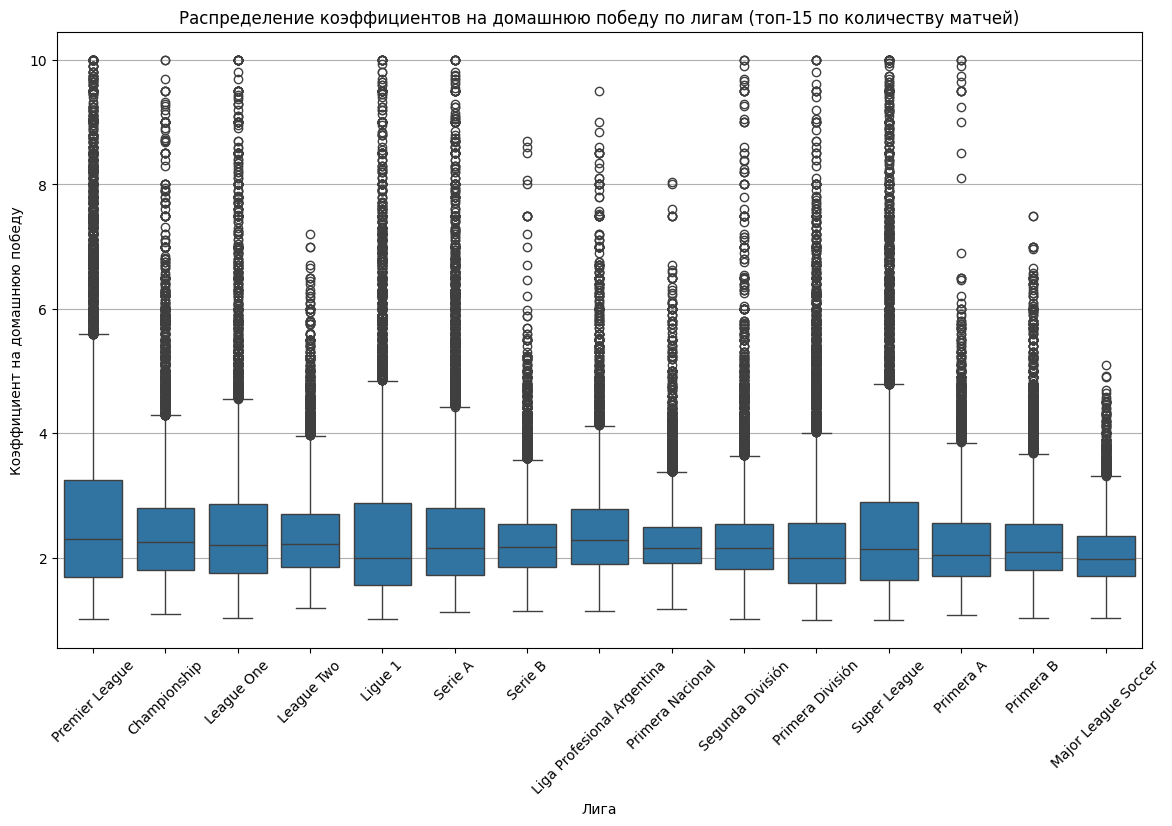

In [ ]:
df_filtered = df[df['Match Winner_Home'] <= 10]

top_leagues = df_filtered['leagueName'].value_counts().head(15).index
df_top_leagues = df_filtered[df_filtered['leagueName'].isin(top_leagues)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_leagues, x='leagueName', y='Match Winner_Home')

plt.xticks(rotation=45)
plt.xlabel('Лига')
plt.ylabel('Коэффициент на домашнюю победу')
plt.title('Распределение коэффициентов на домашнюю победу по лигам (топ-15 по количеству матчей)')
plt.grid(True,axis='y')
plt.show()

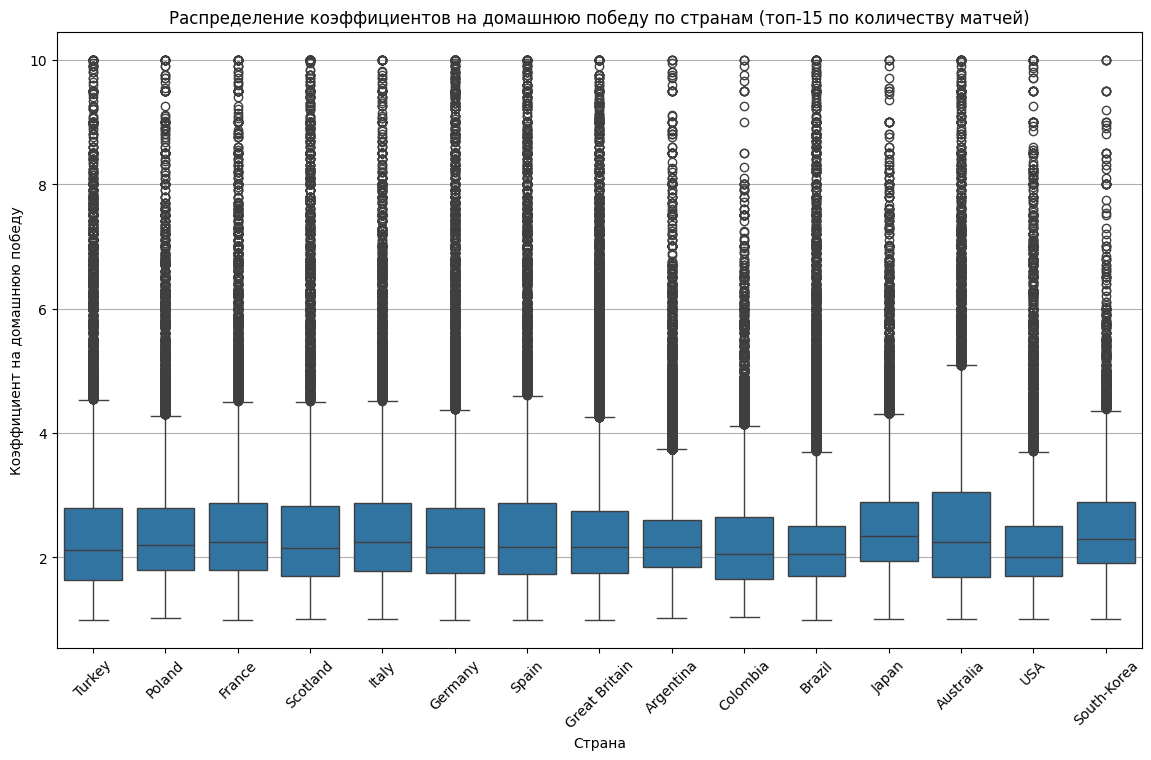

In [ ]:
top_countries = df_filtered['homeTeamCountry'].value_counts().head(15).index
df_top_countries = df_filtered[df_filtered['homeTeamCountry'].isin(top_countries)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_countries,
            x='homeTeamCountry',
            y='Match Winner_Home')

plt.xticks(rotation=45)
plt.xlabel('Страна')
plt.ylabel('Коэффициент на домашнюю победу')
plt.title('Распределение коэффициентов на домашнюю победу по странам (топ-15 по количеству матчей)')
plt.grid(True, axis='y')
plt.show()

# **2.1 bk_offers_history_normal**

In [ ]:
df2 = pd.read_csv('bk_offers_history_normal-20251106_160848.csv')

In [ ]:
print(df2['sport_key'].unique())

['americanfootball_ncaaf' 'americanfootball_nfl' 'basketball_nba'
 'icehockey_nhl' 'soccer_fa_cup' 'icehockey_sweden_allsvenskan'
 'soccer_efl_champ' 'soccer_italy_serie_b']


In [ ]:
grouped_odds = df2.groupby(['sport_key', 'event_id', 'outcome_name', 'bookmaker_title'])
odds_std = grouped_odds['outcome_odds'].std().reset_index(name='std_deviation')
odds_std = odds_std.dropna()

sport_variability = odds_std.groupby('sport_key')['std_deviation'].agg(['mean', 'count']).reset_index()
sport_variability = sport_variability.rename(columns={'mean': 'avg_std_deviation', 'count': 'observation_count'})

sport_variability

,sport_key,avg_std_deviation,observation_count
0,americanfootball_ncaaf,0.427786,630
1,americanfootball_nfl,0.973598,96
2,basketball_nba,0.672172,84
3,icehockey_nhl,0.940548,74
4,icehockey_sweden_allsvenskan,0.065582,121
5,soccer_efl_champ,0.270850,271
6,soccer_fa_cup,1.092108,76
7,soccer_italy_serie_b,0.191926,229


In [ ]:
bookmaker_spread = df2.groupby(['sport_key', 'event_id', 'outcome_name'])['outcome_odds'].std().reset_index(name='std_deviation')

bookmaker_spread_filled = bookmaker_spread.fillna(0)

sport_spread_avg = bookmaker_spread_filled.groupby('sport_key')['std_deviation'].agg(['mean', 'count']).reset_index()
sport_spread_avg = sport_spread_avg.rename(columns={'mean': 'avg_std_deviation', 'count': 'observation_count'})

sport_spread_avg

,sport_key,avg_std_deviation,observation_count
0,americanfootball_ncaaf,0.467019,184
1,americanfootball_nfl,0.717836,48
2,basketball_nba,0.448612,72
3,icehockey_nhl,0.597329,105
4,icehockey_sweden_allsvenskan,0.190559,55
5,soccer_efl_champ,0.382863,60
6,soccer_fa_cup,0.389911,195
7,soccer_italy_serie_b,0.331339,50


['americanfootball_ncaaf' 'americanfootball_nfl' 'basketball_nba'
 'icehockey_nhl' 'icehockey_sweden_allsvenskan' 'soccer_efl_champ'
 'soccer_fa_cup' 'soccer_italy_serie_b']


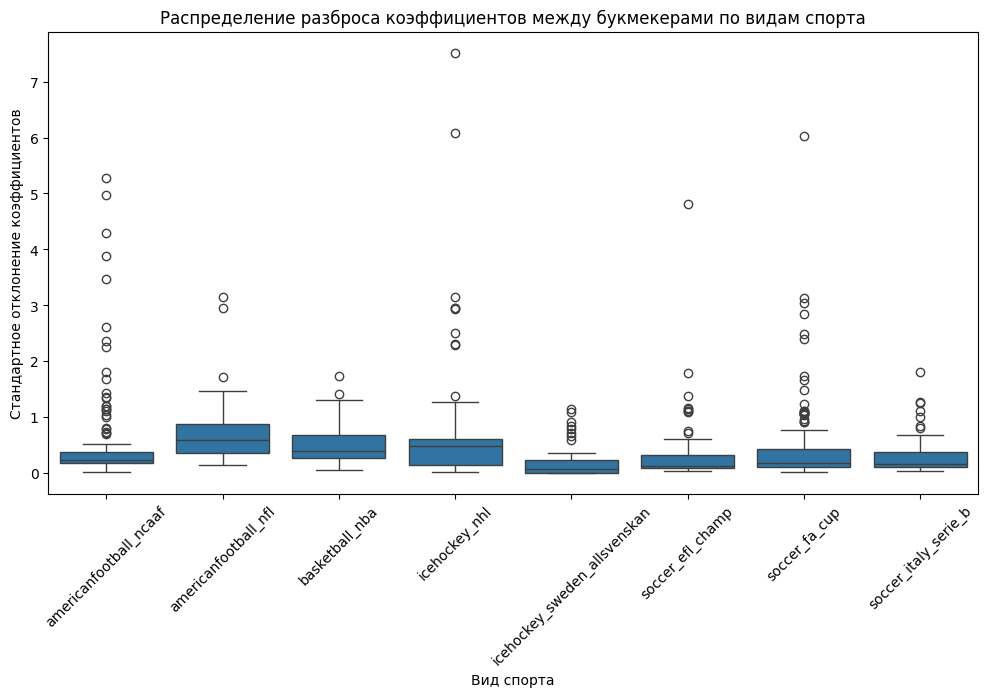

In [ ]:
print(bookmaker_spread['sport_key'].unique())
plt.figure(figsize=(12, 6))
sns.boxplot(data=bookmaker_spread, x='sport_key', y='std_deviation')
plt.title('Распределение разброса коэффициентов между букмекерами по видам спорта')
plt.xlabel('Вид спорта')
plt.ylabel('Стандартное отклонение коэффициентов')
plt.xticks(rotation=45)
plt.show()

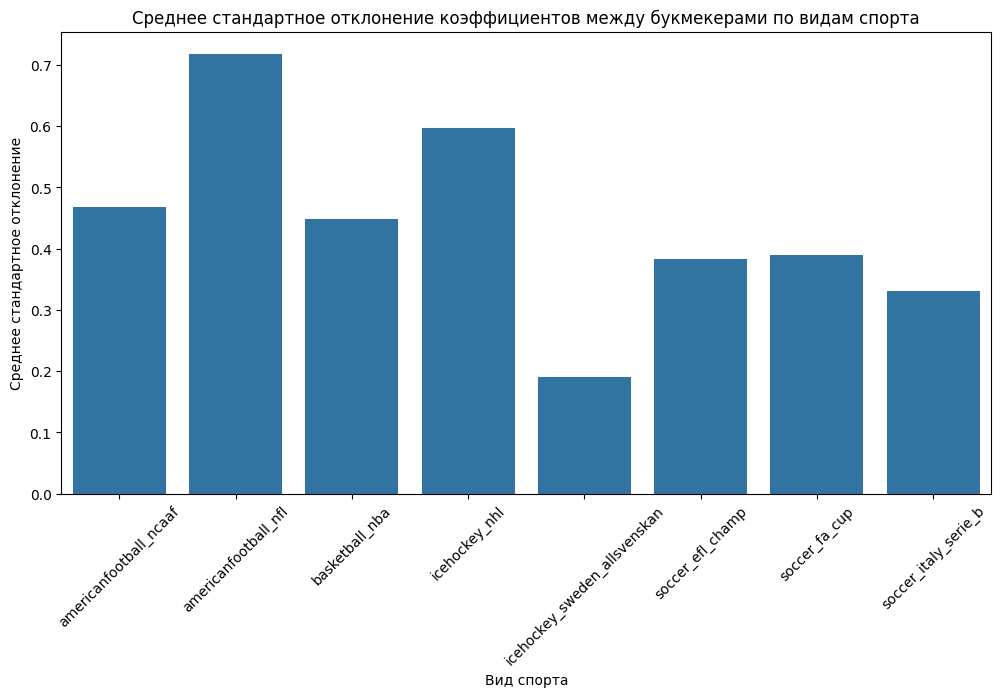

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=sport_spread_avg, x='sport_key', y='avg_std_deviation')
plt.title('Среднее стандартное отклонение коэффициентов между букмекерами по видам спорта')
plt.xlabel('Вид спорта')
plt.ylabel('Среднее стандартное отклонение')
plt.xticks(rotation=45)
plt.show()

# **3.1**

In [ ]:
unique_home_teams = df2.groupby('sport_key')['home_team'].nunique().reset_index()
unique_away_teams = df2.groupby('sport_key')['away_team'].nunique().reset_index()

# подсчет общего колва команд
unique_teams_per_sport = unique_home_teams.merge(unique_away_teams, on='sport_key')
unique_teams_per_sport['total_unique_teams'] = unique_teams_per_sport['home_team'] + unique_teams_per_sport['away_team']

# sort по убыванию колва
unique_teams_per_sport = unique_teams_per_sport.sort_values('total_unique_teams', ascending=False)

unique_teams_per_sport

,sport_key,home_team,away_team,total_unique_teams
0,americanfootball_ncaaf,46,46,92
6,soccer_fa_cup,39,39,78
2,basketball_nba,18,19,37
3,icehockey_nhl,18,17,35
1,americanfootball_nfl,12,12,24
5,soccer_efl_champ,12,12,24
7,soccer_italy_serie_b,10,10,20
4,icehockey_sweden_allsvenskan,9,10,19


In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# объединение данных
correlation_data = sport_spread_avg.merge(unique_teams_per_sport[['sport_key', 'total_unique_teams']],
                                         on='sport_key')

# Пирсон
correlation_coef, p_value = pearsonr(correlation_data['total_unique_teams'],
                                   correlation_data['avg_std_deviation'])

print(f"Корреляция между количеством команд и вариативностью коэффициентов: {correlation_coef:}")
print(f"P-value: {p_value:}")

if abs(correlation_coef) >= 0.7:
    strength = "сильная"
elif abs(correlation_coef) >= 0.5:
    strength = "умеренная"
elif abs(correlation_coef) >= 0.3:
    strength = "слабая"
else:
    strength = "очень слабая"

if correlation_coef > 0:
    direction = "положительная"
elif correlation_coef < 0:
    direction = "отрицательная"
else:
    direction = "нулевая"

print(f"Интерпретация: {strength} {direction} корреляция")

Корреляция между количеством команд и вариативностью коэффициентов: 0.08071353099768255
P-value: 0.8493181227298708
Интерпретация: очень слабая положительная корреляция


P.s. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html

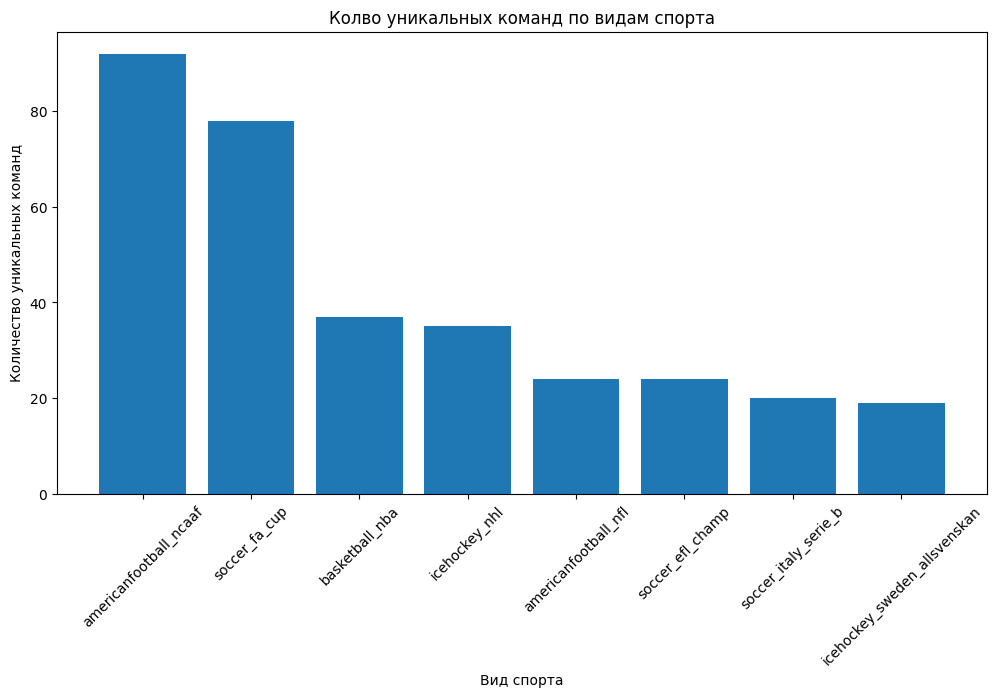

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(unique_teams_per_sport['sport_key'], unique_teams_per_sport['total_unique_teams'])
plt.title('Колво уникальных команд по видам спорта')
plt.xlabel('Вид спорта')
plt.ylabel('Количество уникальных команд')
plt.xticks(rotation=45)
plt.show()

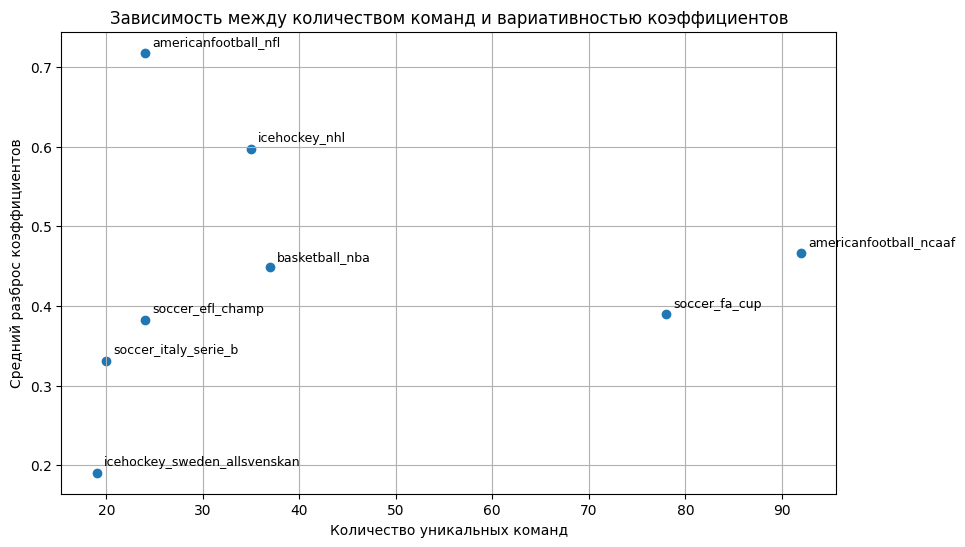

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(correlation_data['total_unique_teams'],
            correlation_data['avg_std_deviation'])

for i, row in correlation_data.iterrows():
    plt.annotate(row['sport_key'],
                (row['total_unique_teams'], row['avg_std_deviation']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9)

plt.title('Зависимость между количеством команд и вариативностью коэффициентов')
plt.xlabel('Количество уникальных команд')
plt.ylabel('Средний разброс коэффициентов')
plt.grid(True)
plt.show()

# ***experts_top-20251109_000000.csv***

# **2.1**

In [ ]:
df3 = pd.read_csv('experts_top-20251109_000000.csv')
df3.head()

,Name,ROI,Place_in_top,Predicted_outcome,Coefficient,Outcome,Team1,Team2,League,Date
0,Владислав Туров,7.37,1,"ТБ(3,5) карточки",2.45,0,АЗ,ПСВ,Эредивизи,2025-11-09
1,Владислав Туров,7.37,1,"ИТБ1(84,5) % точн. передач",1.85,1,Эльче,Реал Сосьедад,Ла Лига,2025-11-07
2,Владислав Туров,7.37,1,"ТБ (25,5) фола",1.76,0,Реал Бетис,Лион,Лига Европы,2025-11-06
3,Владислав Туров,7.37,1,"ИТБ2(12,5) фола",2.01,1,Ньюкасл,Атлетик Бильбао,Лига чемпионов,2025-11-05
4,Владислав Туров,7.37,1,"ТБ (34,5) отбора",1.85,1,ПСЖ,Бавария,Лига чемпионов,2025-11-04


In [ ]:
predicted_outcome_counts = df3['Predicted_outcome'].value_counts().reset_index()
predicted_outcome_counts.columns = ['Predicted_outcome', 'Frequency']

# частота значений
league_counts = df3['League'].value_counts().reset_index()
league_counts.columns = ['League', 'Frequency']

# топ значения
top_predicted_outcome = predicted_outcome_counts.head(20)

top_league = league_counts.head(20)

print("20 самых популярных предсказаний:")
print(top_predicted_outcome)

print("\n20 самых популярных лиг:")
print(top_league)

20 самых популярных предсказаний:
           Predicted_outcome  Frequency
0                 обе забьют        643
1                         П1        630
2   ТМ (10,5) угловых ударов        502
3                         П2        501
4      ТБ (2,5) и обе забьют        432
5                   ТМ (2,5)        410
6                  Ф1 (-1,5)        288
7                   ТБ (2,5)        266
8                    Ф1 (-1)        221
9                         Х2        185
10   ТМ (9,5) угловых ударов        185
11                    Ф2 (0)        175
12                Обе забьют        161
13   ТБ (8,5) угловых ударов        160
14                    Ф1 (0)        143
15                    ТБ (3)        135
16                   Ф2 (-1)        134
17                        1Х        134
18                         Х        109
19             1Х и ТМ (3,5)        104

20 самых популярных лиг:
                             League  Frequency
0                  Неизвестная лига        895
1     

In [ ]:
# средний Winning Rate
predicted_outcome_success = df3.groupby('Predicted_outcome').agg(winning_rate=('Outcome', 'mean'), avg_roi=('ROI', 'mean')).reset_index()

league_success = df3.groupby('League').agg(winning_rate=('Outcome', 'mean'), avg_roi=('ROI', 'mean')).reset_index()

top_predicted_outcome = predicted_outcome_success.loc[predicted_outcome_success['winning_rate'].idxmax()]

top_league = league_success.loc[league_success['winning_rate'].idxmax()]

print("Средний Winning Rate и ROI для каждого Predicted_outcome:")
print(predicted_outcome_success)

print("\nСредний Winning Rate и ROI для каждого League:")
print(league_success)

print("\nPredicted_outcome с наибольшим Winning Rate и ROI:")
print(top_predicted_outcome)

print("\nLeague с наибольшим Winning Rate и ROI:")
print(top_league)

Средний Winning Rate и ROI для каждого Predicted_outcome:
                    Predicted_outcome  winning_rate  avg_roi
0                       !Х и ТМ (3,5)           1.0   6.4600
1     "Арсенал" забьёт в первом тайме           0.0  -8.5000
2                     "Брюгге" забьет           0.0  -0.0100
3              "Вильярреал" не забьет           1.0  -0.0100
4      "Динамо" забьет в обоих таймах           0.0 -11.7700
...                               ...           ...      ...
1937                точный счёт - 2:1           0.5  -8.5000
1938                точный счёт - 3:0           0.0 -68.8300
1939          угловые 11 и более - да           0.5  13.3500
1940                    удаление - да           0.0   7.8875
1941            удары по воротам - 1Х           1.0   7.3700

[1942 rows x 3 columns]

Средний Winning Rate и ROI для каждого League:
                                  League  winning_rate  avg_roi
0                1/4 финала Кубка Англии      1.000000    -2.56
1        

In [ ]:
predicted_outcome_by_group = df3.groupby('Predicted_outcome').size().reset_index(name='Frequency')
league_by_group = df3.groupby('League').size().reset_index(name='Frequency')

top_predicted_outcome = predicted_outcome_by_group.nlargest(5, 'Frequency').reset_index(drop=True)
top_league = league_by_group.nlargest(5, 'Frequency').reset_index(drop=True)

predicted_outcome_success = df3.groupby('Predicted_outcome').agg(winning_rate=('Outcome', 'mean'),avg_roi=('ROI', 'mean')).reset_index()

league_success = df3.groupby('League').agg(winning_rate=('Outcome', 'mean'),avg_roi=('ROI', 'mean')).reset_index()

top_predicted_outcome_success = predicted_outcome_success[predicted_outcome_success['Predicted_outcome'].isin(top_predicted_outcome['Predicted_outcome'])]

top_league_success = league_success[league_success['League'].isin(top_league['League'])]

print("Топ-5 популярных Predicted_outcome среди всех экспертов:")
print(top_predicted_outcome)

print("\nТоп 5 популярных League среди всех экспертов:")
print(top_league)

print("\nСредний Winning Rate и ROI для топ-5 Predicted_outcome среди всех экспертов:")
print(top_predicted_outcome_success)

print("\nСредний Winning Rate и ROI для топ-5 League среди всех экспертов:")
print(top_league_success)

Топ-5 популярных Predicted_outcome среди всех экспертов:
          Predicted_outcome  Frequency
0                обе забьют        643
1                        П1        630
2  ТМ (10,5) угловых ударов        502
3                        П2        501
4     ТБ (2,5) и обе забьют        432

Топ 5 популярных League среди всех экспертов:
             League  Frequency
0  Неизвестная лига        895
1           Примера        385
2    Лига чемпионов        291
3       Первая лига        263
4           Серия А        222

Средний Winning Rate и ROI для топ-5 Predicted_outcome среди всех экспертов:
             Predicted_outcome  winning_rate   avg_roi
769                         П1      0.531746 -1.830683
848                         П2      0.499002 -1.079661
1021     ТБ (2,5) и обе забьют      0.483796 -5.011551
1232  ТМ (10,5) угловых ударов      0.667331 -2.660000
1779                обе забьют      0.552100 -3.637776

Средний Winning Rate и ROI для топ-5 League среди всех экспертов:
 

In [ ]:
predicted_outcome_by_group = df3.groupby('Predicted_outcome').size().reset_index(name='Frequency')
league_by_group = df3.groupby('League').size().reset_index(name='Frequency')

top_predicted_outcome = predicted_outcome_by_group.nlargest(10, 'Frequency').reset_index(drop=True)
top_league = league_by_group.nlargest(5, 'Frequency').reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.bar(top_predicted_outcome['Predicted_outcome'], top_predicted_outcome['Frequency'], color='blue')
plt.xlabel('Predicted_outcome')
plt.ylabel('Частота')
plt.title('Топ-5 популярных Predicted_outcome среди всех экспертов')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(top_league['League'], top_league['Frequency'], color='red')
plt.xlabel('League')
plt.ylabel('Частота')
plt.title('Топ-5 популярных League среди всех экспертов')
plt.xticks(rotation=45)
plt.show()

predicted_outcome_by_group = df3.groupby(['Predicted_outcome']).size().reset_index(name='Frequency')
league_by_group = df3.groupby(['League']).size().reset_index(name='Frequency')

plt.figure(figsize=(10, 6))
plt.bar(top_predicted_outcome['Predicted_outcome'], top_predicted_outcome['Frequency'], color='blue')
plt.xlabel('Predicted_outcome')
plt.ylabel('Частота')
plt.title('Топ-5 популярных Predicted_outcome среди всех экспертов')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(top_league['League'], top_league['Frequency'], color='red')
plt.xlabel('League')
plt.ylabel('Частота')
plt.title('Топ-5 популярных League среди всех экспертов')
plt.xticks(rotation=45)
plt.show()

NameError: name 'df3' is not defined

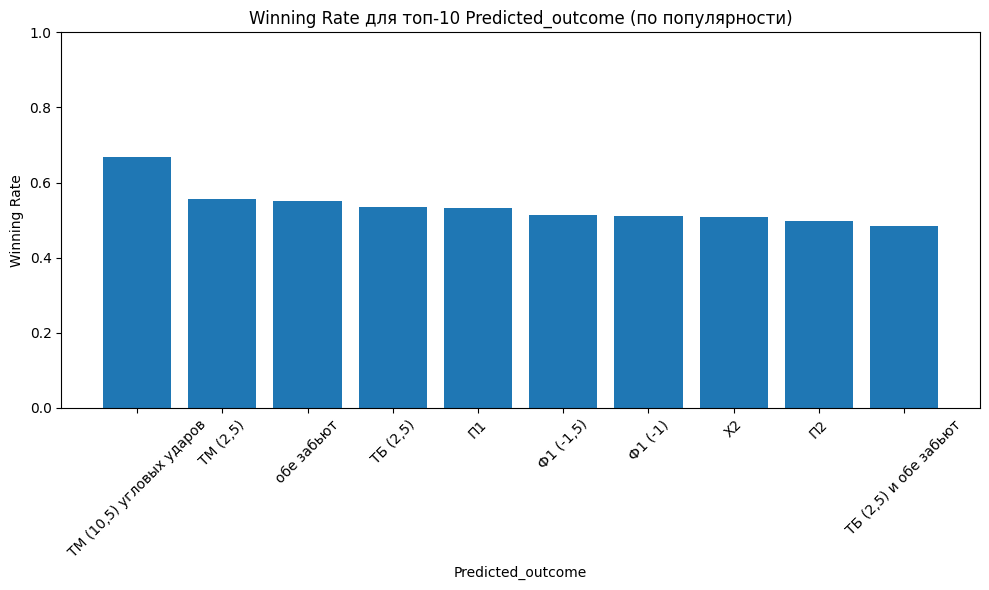

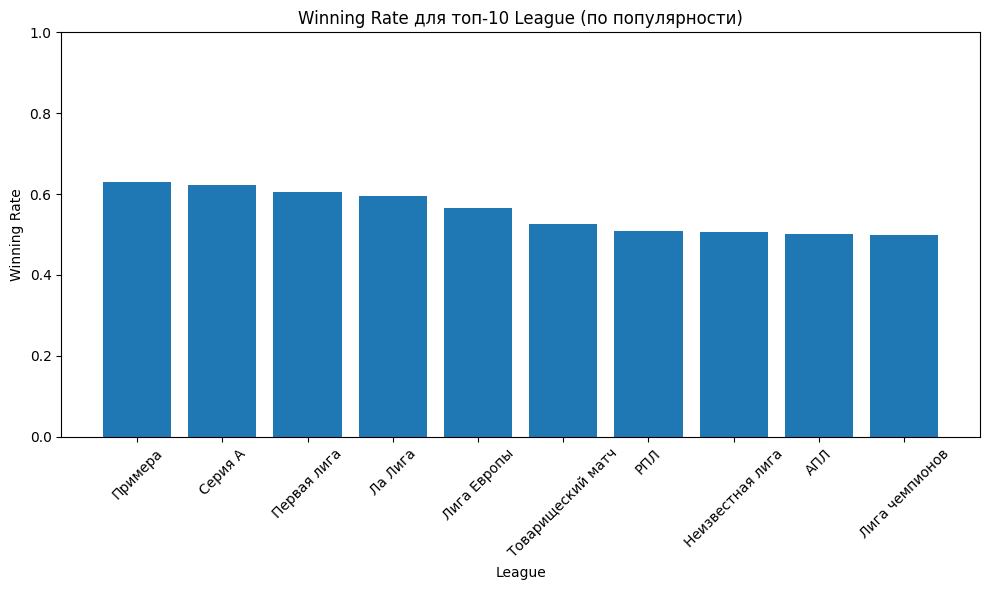

In [ ]:
top_n = 10

# подготовим данные
df3['Outcome'] = pd.to_numeric(df3['Outcome'], errors='coerce')

# частота
po_counts = df3['Predicted_outcome'].value_counts().head(top_n)
po_top = po_counts.index

po_wr = (
    df3.groupby('Predicted_outcome')['Outcome'].mean().loc[po_top].sort_values(ascending=False)
)

# топ n
lg_counts = df3['League'].value_counts().head(top_n)
lg_top = lg_counts.index

# Winning Rate по League
lg_wr = (
    df3.groupby('League')['Outcome'].mean().loc[lg_top].sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(po_wr.index.astype(str), po_wr.values)
plt.title(f'Winning Rate для топ-{top_n} Predicted_outcome (по популярности)')
plt.xlabel('Predicted_outcome')
plt.ylabel('Winning Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(lg_wr.index.astype(str), lg_wr.values)
plt.title(f'Winning Rate для топ-{top_n} League (по популярности)')
plt.xlabel('League')
plt.ylabel('Winning Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

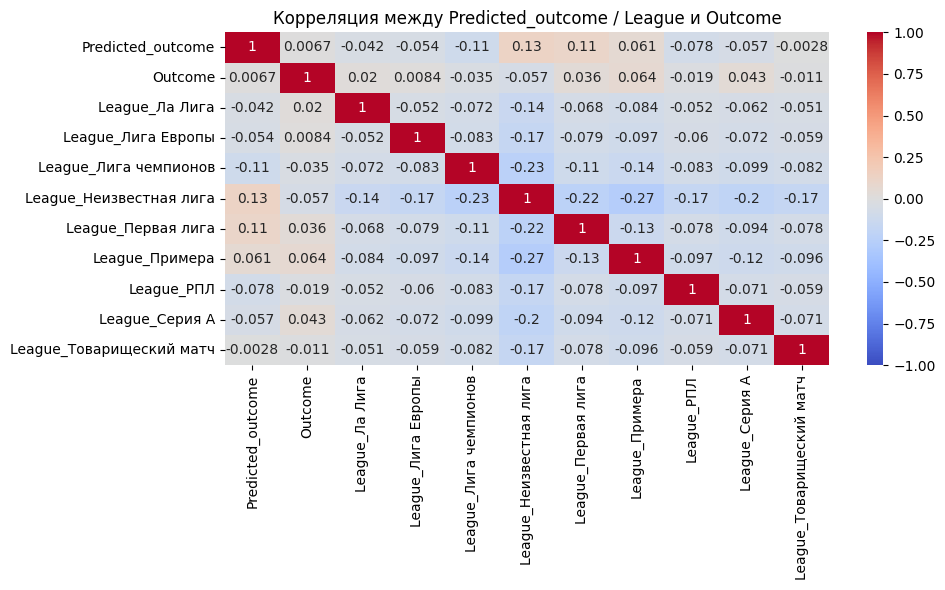

In [ ]:

df3_encoded = df3.copy()

df3_encoded['Predicted_outcome'] = df3_encoded['Predicted_outcome'].astype('category').cat.codes

top_n = 10
top_leagues = df3['League'].value_counts().head(top_n).index
df3_encoded = df3_encoded[df3_encoded['League'].isin(top_leagues)]

df3_encoded = pd.get_dummies(df3_encoded, columns=['League'], drop_first=True)

corr_matrix_all = df3_encoded[['Predicted_outcome', 'Outcome'] + [col for col in df3_encoded.columns if 'League' in col]].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция между Predicted_outcome / League и Outcome')
plt.show()